# FAMLDL — Comprehensive Road Scene Understanding for Autonomous Driving
### Politecnico di Torino · FAIMDL Course Project 1 · Group Repo

## 🚗 Project goal

Adapt a **mask-classification segmentation model (EoMT, CVPR 2025)** from generic image scenes (COCO) to autonomous-driving scenes (Cityscapes), and use it for **out-of-distribution anomaly detection** on five urban anomaly datasets.

## 👥 Team & ownership

| Person | Branch | Steps | Status |
|---|---|---|---|
| **Shayan Bagheri** | `p1-infra` | Step 4 (EoMT comparison) + shared modules | ✅ Done |
| **Shahrzad Shivaei** | `p2-train` | Step 5 (fine-tuning: head-only / partial / LoRA) | ✅ Done |
| **Mim** | `p3-baselines` | Step 7 (ERFNet pixel-based anomaly) | ⏳ In progress |
| **Shabab** | `p4-eval` | Step 8 (EoMT mask-based anomaly + RbA + temperature scaling) | ⏳ In progress |

## 📊 Results so far

| Method | mIoU (19 cls) | mIoU (17 cls fair) | Trainable params |
|---|---|---|---|
| EoMT-COCO zero-shot (mapped) | 55.00 | 61.47 | 0% |
| **Step 5.1 — head-only** | **75.52** | 77.09 | 6.9% |
| **Step 5.2 — partial (last 2 blocks)** | **79.75** | 81.41 | 21.8% |
| **Step 5.3 — LoRA (rank 8, α=16)** | **79.34** | 80.83 | 7.2% |
| EoMT-Cityscapes (paper reference) | 81.45 | 82.78 | 100% |

**Headline finding:** LoRA matches partial unfreeze within 0.41 mIoU at 1/3 the parameter budget. LoRA wins outright on 14 of 19 individual classes.

## 🗂️ Project layout

```
FAMLDL/                              ← repo root (this notebook lives here)
├── eomt/                            ← upstream EoMT source (tue-mps/eomt)
│   └── configs/finetune/README.md   ← documents Step 5 hyperparameters
├── p1_infra/                        ← Shayan's shared modules
│   ├── cityscapes_loader.py         ← native 1024×2048, raw [0,255]
│   ├── class_mapping.py             ← COCO→Cityscapes (from EoMT's own CLASS_MAPPING)
│   ├── miou_eval.py                 ← 19-cls + 17-cls fair confusion-matrix mIoU
│   └── eomt_loader.py               ← load_eomt + windowed_semantic_inference
├── FAMLDL.ipynb                     ← this notebook
└── STEP5_RESULTS.md                 ← full per-class IoU + methodology

Google Drive: /content/drive/MyDrive/FAMLDL/
├── eomt_coco.bin               ← original paper ckpt (357 MB)
├── eomt_cityscapes.bin         ← original paper ckpt (364 MB)
├── leftImg8bit_trainvaltest.zip
├── gtFine_trainvaltest.zip
├── Anomaly_Validation_Datasets.zip
├── checkpoints/
│   ├── exp_5_1_head_only.bin    ← 75.52 mIoU (clean .bin, loadable by load_eomt)
│   ├── exp_5_2_partial.bin      ← 79.75 mIoU
│   └── exp_5_3_lora.bin         ← 79.34 mIoU (LoRA merged into base weights)
└── results/
    ├── step4/step4_results.json
    └── step5/exp_5_{1,2,3}_*_eval.json
```

## ▶️ How to use this notebook

1. **Set `MY_BRANCH`** in Cell 1 (next cell) to your branch name (`p1-infra`, `p2-train`, `p3-baselines`, `p4-eval`)
2. **Run Cell 1** — clones repo, mounts Drive, extracts datasets, copies checkpoints
3. **Jump to your section** below (Step 4 / Step 5 / Step 7 / Step 8)
4. **Don't run cells outside your branch** unless you understand what they do — some are heavy training runs (5-14 hours), some write to Drive

> ⚠️ **Critical hygiene rule for teammates:** the evaluation cells (Step 4 · G, Step 5 · E/G/J) WRITE the result JSONs. If you re-run them when Cityscapes data is missing from `/content/`, you'll overwrite valid results with zeros. Always check `CityscapesValDataset: 500 samples (val)` in the output before trusting the mIoU number.

---


In [1]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 1 — SESSION SETUP (run once per Colab session)     ║
# ╚══════════════════════════════════════════════════════════╝
# Each teammate sets MY_BRANCH to their own branch:
#   p1-infra      → Shayan    (Step 4 + shared p1_infra/ modules)
#   p2-train      → Shahrzad  (Step 5 fine-tuning)
#   p3-baselines  → Mim       (Step 7 ERFNet anomaly)
#   p4-eval       → Shabab    (Step 8 EoMT anomaly + RbA)

import os, sys, zipfile, shutil
from google.colab import drive, userdata
from pathlib import Path

# ── EDIT THIS LINE before first run ──
MY_BRANCH = 'p4-eval'

# ── Constants (the same for every teammate) ──
DRIVE       = Path('/content/drive/MyDrive/FAMLDL')
REPO_URL    = 'github.com/Shayan19950405/FAMLDL.git'
LOCAL_REPO  = '/content/project'
CKPT_DIR    = Path('/content/checkpoints')
CS_DIR      = Path('/content/cityscapes')
ANOMALY_DIR = Path('/content/anomaly_datasets')

drive.mount('/content/drive', force_remount=False)

# Token: GITHUB_TOKEN for Shayan / Mim / Shabab, Shahrzad_Git for Shahrzad
token = userdata.get('Shahrzad_Git' if MY_BRANCH == 'p2-train' else 'GITHUB_TOKEN')

# ── 1. Clone repo (idempotent) ──
if not Path(f'{LOCAL_REPO}/.git').exists():
    os.system(f'git clone https://{token}@{REPO_URL} {LOCAL_REPO}')
    print('✅ Repo cloned')
else:
    print('[SKIP] Repo already cloned')

os.system(f'git -C {LOCAL_REPO} remote set-url origin https://{token}@{REPO_URL}')
os.system(f'git -C {LOCAL_REPO} checkout {MY_BRANCH}')
os.system(f'git -C {LOCAL_REPO} pull origin {MY_BRANCH}')

# ── 2. Install dependencies ──
os.system('pip install -q timm einops transformers safetensors '
          'pytorch-lightning lightning torchmetrics pycocotools '
          'gdown wandb omegaconf hydra-core '
          'albumentations opencv-python-headless scikit-learn tqdm')

# ── 3. Cityscapes dataset (needed for P1, P2, P3 — NOT for P4) ──
if MY_BRANCH != 'p4-eval':
    if not (CS_DIR / 'leftImg8bit' / 'val').exists():
        CS_DIR.mkdir(exist_ok=True)
        for zname in ['leftImg8bit_trainvaltest.zip', 'gtFine_trainvaltest.zip']:
            zp = DRIVE / zname
            if zp.exists():
                print(f'Extracting {zname} ...')
                with zipfile.ZipFile(zp) as z:
                    z.extractall(CS_DIR)
            else:
                print(f'[WARN] {zname} not found in {DRIVE}')
        print('✅ Cityscapes ready')
    else:
        print('[SKIP] Cityscapes already extracted')
else:
    print('[SKIP] Cityscapes not needed for P4')

# ── 4. Anomaly datasets (needed for P3, P4 only) ──
if MY_BRANCH in ('p3-baselines', 'p4-eval'):
    if not ANOMALY_DIR.exists() or not any(ANOMALY_DIR.iterdir()):
        ANOMALY_DIR.mkdir(exist_ok=True)
        az = DRIVE / 'Anomaly_Validation_Datasets.zip'
        if az.exists():
            local_zip = Path('/content/anomaly.zip')
            print('Copying zip locally...')
            shutil.copy2(az, local_zip)
            print('Extracting...')
            with zipfile.ZipFile(local_zip) as z:
                z.extractall(ANOMALY_DIR)
            local_zip.unlink()
            print('✅ Anomaly datasets ready')
        else:
            print(f'[WARN] Anomaly_Validation_Datasets.zip not found in {DRIVE}')
    else:
        print('[SKIP] Anomaly datasets already unzipped')

# ── 5. EoMT checkpoints (everyone needs these) ──
CKPT_DIR.mkdir(exist_ok=True)
for ck in ['eomt_coco.bin', 'eomt_cityscapes.bin']:
    src = DRIVE / ck
    dst = CKPT_DIR / ck
    if not dst.exists() and src.exists():
        shutil.copy2(src, dst)
        print(f'✅ Copied {ck}')
    elif dst.exists():
        print(f'[SKIP] {ck} already in /content/checkpoints')
    else:
        print(f'[WARN] {ck} not found at {src}')

# ── 6. Python path setup ──
sys.path.insert(0, '/content/project/eomt')
sys.path.insert(0, '/content/project/p1_infra')
os.chdir('/content/project/eomt')

# ── 7. GPU check ──
import torch
gpu = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'

print('\n' + '=' * 50)
print('✅ SESSION SETUP COMPLETE')
print(f'   Branch : {MY_BRANCH}')
print(f'   GPU    : {gpu}')
print(f'   Drive  : {DRIVE}')
print('=' * 50)


Mounted at /content/drive
✅ Repo cloned
[SKIP] Cityscapes not needed for P4
Copying zip locally...
Extracting...
✅ Anomaly datasets ready
✅ Copied eomt_coco.bin
✅ Copied eomt_cityscapes.bin

✅ SESSION SETUP COMPLETE
   Branch : p4-eval
   GPU    : Tesla T4
   Drive  : /content/drive/MyDrive/FAMLDL


In [ ]:
import shutil, subprocess

# Copy the (already-clean) Drive notebook into the git repo
shutil.copy('/content/drive/MyDrive/FAMLDL/FAMLDL.ipynb',
            '/content/project/FAMLDL.ipynb')
print('✓ Copied Drive notebook into repo')

def run(cmd):
    return subprocess.run(cmd, shell=True, capture_output=True, text=True,
                          cwd='/content/project').stdout.strip()

run('git config user.name  "Shahrzad Shivaei"')
run('git config user.email "shivaei199@gmail.com"')

# Check if there are actually changes vs what's in git
status = run('git status --short FAMLDL.ipynb')
print(f"\nGit status for FAMLDL.ipynb: {status if status else '(no changes — already committed)'}")

if status:
    run('git add FAMLDL.ipynb')
    print('\n── commit ──')
    print(run('git commit -m "[P2] Update notebook: clean Cell 1, convergence chart, all results preserved"'))
    print('\n── push ──')
    print(run('git push origin p2-train'))
else:
    print("Notebook in repo already matches Drive — nothing to push")

print(f"\nLocal final  : {run('git log --oneline -1')}")
print(f"Remote final : {run('git log --oneline -1 origin/p2-train')}")

✓ Copied Drive notebook into repo

Git status for FAMLDL.ipynb: ?? FAMLDL.ipynb

── commit ──
[p2-train c54e570] [P2] Update notebook: clean Cell 1, convergence chart, all results preserved
 1 file changed, 1 insertion(+)
 create mode 100644 FAMLDL.ipynb

── push ──


Local final  : c54e570 [P2] Update notebook: clean Cell 1, convergence chart, all results preserved
Remote final : c54e570 [P2] Update notebook: clean Cell 1, convergence chart, all results preserved


---
## STEP 4 — Compare Two Pre-trained EoMT Models
**Owner: Shayan (P1) · Branch: `p1-infra`**

Goal: evaluate EoMT-COCO (640×640, 133 classes, 200 queries) and EoMT-Cityscapes (1024×1024, 19 classes, 100 queries) on Cityscapes val using a consistent pipeline.

**Validated against:**
- EoMT paper (CVPR 2025) Sec. A.3: windowed semantic inference
- `eomt/training/lightning_module.py::to_per_pixel_logits_semantic` for mask+class → per-pixel logits
- `eomt/datasets/coco_panoptic.py::CLASS_MAPPING` for COCO index↔COCO id mapping

Output: 19-class mIoU (standard) and 17-class mIoU (fair — excludes pole/rider which have no COCO equivalent).

---

### Method overview

```
┌─────────────────────────────────────────────────────────────────┐
│  Cityscapes val image  (1024×2048)                              │
└────────────────────────────┬────────────────────────────────────┘
                             │
                ┌────────────┴────────────┐
                │ Windowed inference      │  (EoMT paper §A.3)
                │ tile into 1024×1024     │
                │ overlapping crops       │
                │ → average logits        │
                └────────────┬────────────┘
                             │
        ┌────────────────────┼────────────────────┐
        ▼                                          ▼
┌───────────────┐                          ┌───────────────┐
│ EoMT-COCO     │                          │ EoMT-CS       │
│ 640×640       │                          │ 1024×1024     │
│ 133 classes   │                          │ 19 classes    │
│ 200 queries   │                          │ 100 queries   │
└───────┬───────┘                          └───────┬───────┘
        │  per-pixel logits [134, H, W]             │  per-pixel logits [20, H, W]
        ▼                                            ▼
┌──────────────────────┐                  ┌──────────────────────┐
│ argmax → COCO id     │                  │ argmax → trainId     │
│ COCO→CS mapping      │  (23 entries)    │ (already in trainId) │
│ (eomt's own table)   │                  │                      │
└──────────┬───────────┘                  └──────────┬───────────┘
           │                                          │
           ▼                                          ▼
      Cityscapes trainId predictions [H, W]
                                │
                                ▼
                  ┌─────────────────────────────┐
                  │ Confusion matrix            │
                  │ → mIoU (19 cls standard)    │
                  │ → mIoU (17 cls fair)        │
                  │   excludes pole + rider     │
                  │   no COCO equivalent        │
                  └─────────────────────────────┘
```

**Why "fair 17-class mIoU"?** Cityscapes `pole` (id 5) and `rider` (id 12) have no COCO panoptic equivalent. Including them artificially deflates EoMT-COCO's score (it can never predict those classes) without measuring anything real about the model's transfer ability. The 17-class score excludes these two to give an apples-to-apples comparison.

**Result preview** (full numbers in Cell G):

| Model | mIoU (19 cls) | mIoU (17 cls fair) |
|---|---|---|
| EoMT-COCO (zero-shot, mapped) | 55.00 | 61.47 |
| EoMT-Cityscapes (reference) | 81.45 | 82.78 |


In [ ]:
# ── STEP 4 · Cell A: Cityscapes Val DataLoader ────────────
# Returns images at NATIVE 1024×2048 resolution (uint8 in float).
# EoMT does its own normalization & windowed inference internally.

import torch
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
import numpy as np

class CityscapesValDataset(Dataset):
    CLASSES = [
        'road','sidewalk','building','wall','fence','pole',
        'traffic light','traffic sign','vegetation','terrain','sky',
        'person','rider','car','truck','bus','train','motorcycle','bicycle'
    ]
    ID_TO_TRAINID = {
        0:255, 1:255, 2:255, 3:255, 4:255, 5:255, 6:255,
        7:0, 8:1, 9:255, 10:255, 11:2, 12:3, 13:4, 14:255,
        15:255, 16:255, 17:5, 18:255, 19:6, 20:7, 21:8, 22:9,
        23:10, 24:11, 25:12, 26:13, 27:14, 28:15, 29:255,
        30:255, 31:16, 32:17, 33:18, -1:255,
    }

    def __init__(self, root='/content/cityscapes', split='val'):
        self.root = Path(root)
        img_dir = self.root / 'leftImg8bit' / split
        gt_dir  = self.root / 'gtFine'      / split
        self.samples = []
        for ip in sorted(img_dir.rglob('*_leftImg8bit.png')):
            city = ip.parent.name
            stem = ip.stem.replace('_leftImg8bit','')
            gp = gt_dir / city / f'{stem}_gtFine_labelIds.png'
            if gp.exists(): self.samples.append((ip, gp))
        print(f'CityscapesValDataset: {len(self.samples)} samples ({split})')

    def __len__(self): return len(self.samples)

    def _to_trainids(self, m):
        out = np.full_like(m, 255)
        for lid, tid in self.ID_TO_TRAINID.items():
            out[m == lid] = tid
        return out

    def __getitem__(self, idx):
        ip, gp = self.samples[idx]
        img  = np.array(Image.open(ip).convert('RGB'))
        mask = np.array(Image.open(gp), dtype=np.int32)
        img_t  = torch.from_numpy(img).permute(2,0,1).float()       # [3,1024,2048]
        mask_t = torch.from_numpy(self._to_trainids(mask)).long()   # [1024,2048]
        return img_t, mask_t, str(ip)

ds = CityscapesValDataset(split='val')
img, gt, p = ds[0]
print(f'Image: {tuple(img.shape)}  range=[{img.min():.0f}, {img.max():.0f}]')
print(f'Mask : {tuple(gt.shape)}   unique trainIds first 6: {sorted(gt.unique().tolist())[:6]}')

CityscapesValDataset: 500 samples (val)
Image: (3, 1024, 2048)  range=[0, 255]
Mask : (1024, 2048)   unique trainIds first 6: [0, 1, 2, 4, 5, 7]


In [ ]:
# ── STEP 4 · Cell B: COCO → Cityscapes Class Mapping ──────
# Sourced from EoMT's own datasets/coco_panoptic.py::CLASS_MAPPING.
# Maps model class index (0-132) → Cityscapes trainId (0-18, 255=ignore).

import torch
from datasets.coco_panoptic import CLASS_MAPPING as COCO_CLASS_MAPPING

IDX_TO_COCO_ID = {v: k for k, v in COCO_CLASS_MAPPING.items()}

COCO_MODEL_IDX_TO_CITY = {
    # THINGS
    0: 11,   # person
    1: 18,   # bicycle
    2: 13,   # car
    3: 17,   # motorcycle
    5: 15,   # bus
    6: 16,   # train
    7: 14,   # truck
    9: 6,    # traffic light
    11: 7,   # stop sign → traffic sign
    # STUFF
    82: 2,   # bridge → building
    91: 2,   # house → building
    100: 0,  # road
    109: 3,  # wall-brick → wall
    110: 3,  # wall-stone → wall
    111: 3,  # wall-tile → wall
    112: 3,  # wall-wood → wall
    116: 8,  # tree-merged → vegetation
    117: 4,  # fence-merged → fence
    119: 10, # sky-other-merged → sky
    123: 1,  # pavement-merged → sidewalk
    125: 9,  # grass-merged → terrain
    129: 2,  # building-other-merged → building
    131: 3,  # wall-other-merged → wall
}

_mapping = torch.full((133,), 255, dtype=torch.long)
for mi, ci in COCO_MODEL_IDX_TO_CITY.items():
    _mapping[mi] = ci

def coco_pred_to_cityscapes(pred):
    """[H,W] LongTensor of COCO model indices → Cityscapes trainIds."""
    return _mapping.to(pred.device)[pred]

print(f'Mapped {len(COCO_MODEL_IDX_TO_CITY)}/133 COCO classes → Cityscapes')
covered = set(COCO_MODEL_IDX_TO_CITY.values())
missing = [(c, CityscapesValDataset.CLASSES[c]) for c in range(19) if c not in covered]
print(f'Cityscapes classes WITHOUT COCO mapping ({len(missing)}): {missing}')

Mapped 23/133 COCO classes → Cityscapes
Cityscapes classes WITHOUT COCO mapping (2): [(5, 'pole'), (12, 'rider')]


In [ ]:
# ── STEP 4 · Cell C: mIoU Pipeline (19-cls and fair 17-cls) ──
import torch

NUM_CLASSES = 19
IGNORE = 255
FAIR_EXCLUDE = [5, 12]    # pole, rider — no COCO equivalent
FAIR_CLASSES = [c for c in range(NUM_CLASSES) if c not in FAIR_EXCLUDE]

def new_conf(device='cuda'):
    return torch.zeros((NUM_CLASSES, NUM_CLASSES), dtype=torch.long, device=device)

def update_conf(conf, pred, gt):
    pred = pred.flatten(); gt = gt.flatten()
    valid = (gt != IGNORE) & (pred != IGNORE)
    p, g = pred[valid].long(), gt[valid].long()
    mask = (g >= 0) & (g < NUM_CLASSES) & (p >= 0) & (p < NUM_CLASSES)
    idx = g[mask] * NUM_CLASSES + p[mask]
    conf += torch.bincount(idx, minlength=NUM_CLASSES**2).reshape(NUM_CLASSES, NUM_CLASSES)
    return conf

def miou(conf, subset=None):
    tp = conf.diag().float()
    fp = conf.sum(0).float() - tp
    fn = conf.sum(1).float() - tp
    iou = tp / (tp + fp + fn + 1e-10)
    iou_list = iou.cpu().tolist()
    if subset is None:
        present = (conf.sum(1) > 0).cpu().tolist()
        valid = [v for v, p in zip(iou_list, present) if p]
    else:
        valid = [iou_list[c] for c in subset]
    return (sum(valid)/len(valid) if valid else 0.0), iou_list

def print_report(conf, name='Model'):
    m19, ious = miou(conf)
    m17, _    = miou(conf, subset=FAIR_CLASSES)
    print(f'\n══ {name} ══')
    print(f'  mIoU (19 cls) : {m19*100:.2f}')
    print(f'  mIoU (17 cls) : {m17*100:.2f}  (fair — excludes pole + rider)')
    print('\n  Per-class IoU:')
    for c, n in enumerate(CityscapesValDataset.CLASSES):
        tag = ' [excluded]' if c in FAIR_EXCLUDE else ''
        print(f'    {c:>2} {n:<14} {ious[c]*100:>6.2f}{tag}')
    return {'miou_19': m19, 'miou_17': m17, 'iou_per_class': ious}

print('✅ mIoU pipeline ready')

✅ mIoU pipeline ready


In [ ]:
# ── STEP 4 · Cell D: Load Both EoMT Checkpoints ───────────
# Validated config from configs/dinov2/{coco,cityscapes}/...:
#   EoMT-COCO        : 640×640,  num_classes=133, num_q=200
#   EoMT-Cityscapes  : 1024×1024, num_classes=19,  num_q=100
#   Both: ViT-Base/16 DINOv2, num_blocks=3, masked_attn=True

import torch
from pathlib import Path
from models.eomt import EoMT
from models.vit import ViT

CKPT_DIR = Path('/content/checkpoints')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

def build_eomt(num_classes, num_q, img_size, num_blocks=3,
               backbone='vit_base_patch14_reg4_dinov2', patch_size=16):
    enc = ViT(img_size=img_size, patch_size=patch_size, backbone_name=backbone)
    return EoMT(encoder=enc, num_classes=num_classes, num_q=num_q,
                num_blocks=num_blocks, masked_attn_enabled=True)

def load_eomt(ckpt_path, num_classes, num_q, img_size, device=DEVICE):
    model = build_eomt(num_classes=num_classes, num_q=num_q, img_size=img_size)
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    sd = ckpt.get('state_dict', ckpt) if isinstance(ckpt, dict) else ckpt
    clean = {k[len('network.'):]: v for k, v in sd.items() if k.startswith('network.')}
    miss, unex = model.load_state_dict(clean, strict=False)
    print(f'  Missing={len(miss)}, Unexpected={len(unex)}')
    return model.eval().to(device)

print('Loading EoMT-COCO ...')
model_coco = load_eomt(CKPT_DIR/'eomt_coco.bin',       num_classes=133, num_q=200, img_size=(640,640))
print('✅ EoMT-COCO loaded\n')

print('Loading EoMT-Cityscapes ...')
model_city = load_eomt(CKPT_DIR/'eomt_cityscapes.bin', num_classes=19,  num_q=100, img_size=(1024,1024))
print('✅ EoMT-Cityscapes loaded')

Loading EoMT-COCO ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

  Missing=0, Unexpected=0
✅ EoMT-COCO loaded

Loading EoMT-Cityscapes ...
  Missing=0, Unexpected=0
✅ EoMT-Cityscapes loaded


In [ ]:
# ── STEP 4 · Cell E: EoMT Inference Helpers ───────────────
# Implements:
#  1) to_per_pixel_logits — merges (mask_logits, class_logits) into per-pixel C-channel logits
#     formula from lightning_module.py:
#       logits[b,c,h,w] = Σ_q sigmoid(mask[b,q,h,w]) * softmax(class[b,q,:])[..., c]
#  2) windowed_semantic_inference — sliding-window inference per EoMT paper Sec. A.3:
#       resize shorter side → tile longer side → average overlaps → upsample to original

import math, torch
import torch.nn.functional as F

@torch.no_grad()
def to_per_pixel_logits(mask_logits, class_logits, drop_no_object=True):
    """
    mask_logits  : [B, Q, h, w]
    class_logits : [B, Q, C+1]   (last channel = 'no object')
    Returns      : [B, C, h, w]
    """
    cls = class_logits.softmax(dim=-1)
    if drop_no_object: cls = cls[..., :-1]
    return torch.einsum('bqhw, bqc -> bchw', mask_logits.sigmoid(), cls)


@torch.no_grad()
def windowed_semantic_inference(model, image, crop_size, device='cuda'):
    """
    EoMT windowed semantic inference (paper Sec. A.3).
    image     : [3, H, W] float in [0, 255]  (NO normalization — EoMT does it internally)
    crop_size : 640 for COCO, 1024 for Cityscapes
    Returns   : [C, H, W] per-pixel logits at original resolution
    """
    image = image.float().to(device)
    _, H, W = image.shape

    # 1) Resize shorter side to crop_size, preserve aspect ratio
    short = min(H, W)
    factor = crop_size / short
    new_H, new_W = round(H * factor), round(W * factor)
    img_r = F.interpolate(image.unsqueeze(0), size=(new_H, new_W),
                          mode='bilinear', align_corners=False).squeeze(0)

    # 2) Tile the longer side with crop_size-sized overlapping crops
    long_dim = max(new_H, new_W)
    n = max(1, math.ceil(long_dim / crop_size))
    overlap = n * crop_size - long_dim
    step = (crop_size - overlap / (n - 1)) if n > 1 else 0

    crops, origins = [], []
    for j in range(n):
        start = int(round(j * step))
        end   = start + crop_size
        if new_H > new_W:
            crops.append(img_r[:, start:end, :])
        else:
            crops.append(img_r[:, :, start:end])
        origins.append((start, end))

    batch = torch.stack(crops, dim=0)             # [N,3,crop,crop]
    mask_list, class_list = model(batch / 255.0)  # ← EoMT expects [0,1] range
    mask_logits  = mask_list[-1]                  # final layer only
    class_logits = class_list[-1]

    pp = to_per_pixel_logits(mask_logits, class_logits)        # [N,C,h,w]  (h=w=crop/4)
    pp = F.interpolate(pp, size=(crop_size, crop_size),
                       mode='bilinear', align_corners=False)

    C = pp.shape[1]
    sums   = torch.zeros((C, new_H, new_W), device=device)
    counts = torch.zeros((C, new_H, new_W), device=device)
    for k, (s, e) in enumerate(origins):
        if new_H > new_W:
            sums[:, s:e, :]   += pp[k]
            counts[:, s:e, :] += 1
        else:
            sums[:, :, s:e]   += pp[k]
            counts[:, :, s:e] += 1
    avg = sums / counts.clamp(min=1)

    return F.interpolate(avg.unsqueeze(0), size=(H, W),
                         mode='bilinear', align_corners=False).squeeze(0)

print('✅ Inference helpers ready')
print('   to_per_pixel_logits()        — mask+class → per-pixel C-channel logits')
print('   windowed_semantic_inference()— sliding-window per EoMT paper')

✅ Inference helpers ready
   to_per_pixel_logits()        — mask+class → per-pixel C-channel logits
   windowed_semantic_inference()— sliding-window per EoMT paper


CityscapesValDataset: 500 samples (val)
EoMT-Cityscapes logits (19, 1024, 2048), unique preds: [0, 1, 2, 4, 5, 7, 8, 9, 10, 11]
EoMT-COCO logits (133, 1024, 2048)
  raw COCO indices: [0, 2, 9, 80, 100, 116, 119, 123, 129, 131]
  mapped trainIds : [0, 1, 2, 3, 6, 8, 10, 11, 13, 255]


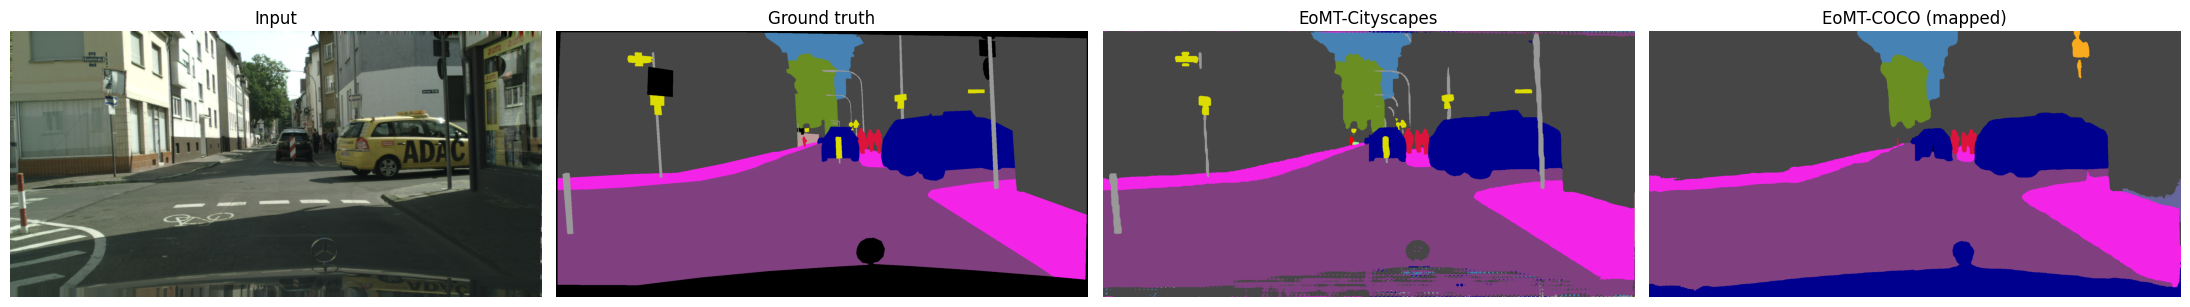

In [ ]:
# ── STEP 4 · Cell F: Smoke Test (1 image) ─────────────────
# Verify shapes, ranges, and visualize predictions side-by-side.

import torch
import numpy as np
import matplotlib.pyplot as plt

ds = CityscapesValDataset(split='val')
img, gt, path = ds[0]
gt_cuda = gt.cuda()

logits_city = windowed_semantic_inference(model_city, img, crop_size=1024)
pred_city   = logits_city.argmax(dim=0)
print(f'EoMT-Cityscapes logits {tuple(logits_city.shape)}, unique preds: {sorted(pred_city.unique().tolist())[:10]}')

logits_coco = windowed_semantic_inference(model_coco, img, crop_size=640)
pred_coco_raw = logits_coco.argmax(dim=0)
pred_coco     = coco_pred_to_cityscapes(pred_coco_raw)
print(f'EoMT-COCO logits {tuple(logits_coco.shape)}')
print(f'  raw COCO indices: {sorted(pred_coco_raw.unique().tolist())[:10]}')
print(f'  mapped trainIds : {sorted(pred_coco.unique().tolist())}')

PAL = np.array([
    (128,64,128),(244,35,232),(70,70,70),(102,102,156),(190,153,153),
    (153,153,153),(250,170,30),(220,220,0),(107,142,35),(152,251,152),
    (70,130,180),(220,20,60),(255,0,0),(0,0,142),(0,0,70),
    (0,60,100),(0,80,100),(0,0,230),(119,11,32)
], dtype=np.uint8)

def colorize(m):
    a = m.cpu().numpy() if torch.is_tensor(m) else m
    out = np.zeros((*a.shape, 3), dtype=np.uint8)
    for c in range(19):
        out[a == c] = PAL[c]
    return out

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes[0].imshow(img.permute(1,2,0).numpy().astype(np.uint8)); axes[0].set_title('Input')
axes[1].imshow(colorize(gt));        axes[1].set_title('Ground truth')
axes[2].imshow(colorize(pred_city)); axes[2].set_title('EoMT-Cityscapes')
axes[3].imshow(colorize(pred_coco)); axes[3].set_title('EoMT-COCO (mapped)')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

In [ ]:
# ── STEP 4 · Cell G: Full Quantitative Evaluation ─────────
# Loops over all 500 val images, accumulates confusion matrices,
# prints per-class IoU and 19/17-class mIoU for both models.
# Saves results JSON to Drive.

import json
import torch
from tqdm.auto import tqdm
from pathlib import Path

ds = CityscapesValDataset(split='val')
conf_city = new_conf()
conf_coco = new_conf()

for i in tqdm(range(len(ds)), desc='Evaluating'):
    img, gt, _ = ds[i]
    gt = gt.cuda()

    lg = windowed_semantic_inference(model_city, img, crop_size=1024)
    update_conf(conf_city, lg.argmax(0), gt)

    lg = windowed_semantic_inference(model_coco, img, crop_size=640)
    update_conf(conf_coco, coco_pred_to_cityscapes(lg.argmax(0)), gt)

res_city = print_report(conf_city, 'EoMT-Cityscapes')
res_coco = print_report(conf_coco, 'EoMT-COCO (mapped to Cityscapes)')

out = Path('/content/drive/MyDrive/FAMLDL/results/step4')
out.mkdir(parents=True, exist_ok=True)
with open(out / 'step4_results.json', 'w') as f:
    json.dump({'EoMT-Cityscapes': res_city, 'EoMT-COCO': res_coco}, f, indent=2)
print(f'\n✅ Saved results JSON to {out}')

CityscapesValDataset: 500 samples (val)


Evaluating:   0%|          | 0/500 [00:00<?, ?it/s]


══ EoMT-Cityscapes ══
  mIoU (19 cls) : 81.45
  mIoU (17 cls) : 82.78  (fair — excludes pole + rider)

  Per-class IoU:
     0 road            98.38
     1 sidewalk        87.19
     2 building        94.09
     3 wall            65.94
     4 fence           65.44
     5 pole            69.52 [excluded]
     6 traffic light   74.57
     7 traffic sign    81.58
     8 vegetation      92.95
     9 terrain         66.49
    10 sky             95.42
    11 person          85.11
    12 rider           70.76 [excluded]
    13 car             95.42
    14 truck           81.86
    15 bus             90.24
    16 train           77.38
    17 motorcycle      74.18
    18 bicycle         81.11

══ EoMT-COCO (mapped to Cityscapes) ══
  mIoU (19 cls) : 55.00
  mIoU (17 cls) : 61.47  (fair — excludes pole + rider)

  Per-class IoU:
     0 road            94.24
     1 sidewalk        65.26
     2 building        86.97
     3 wall            44.27
     4 fence           49.97
     5 pole            

In [ ]:
# ── STEP 4 · Cell H: Package modules for teammates ─────────
# Saves reusable .py files into /content/project/p1_infra/
# Used later by Shahrzad (Step 5 eval) and Shabab (Step 8 eval)

import os
from pathlib import Path

p1 = Path('/content/project/p1_infra')
p1.mkdir(exist_ok=True)

# ── 1. Cityscapes DataLoader (updated to native resolution)
(p1 / 'cityscapes_loader.py').write_text('''"""Cityscapes val DataLoader — native 1024x2048, raw [0,255] images."""
import torch
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
import numpy as np

class CityscapesValDataset(Dataset):
    CLASSES = [
        "road","sidewalk","building","wall","fence","pole",
        "traffic light","traffic sign","vegetation","terrain","sky",
        "person","rider","car","truck","bus","train","motorcycle","bicycle"
    ]
    ID_TO_TRAINID = {
        0:255, 1:255, 2:255, 3:255, 4:255, 5:255, 6:255,
        7:0, 8:1, 9:255, 10:255, 11:2, 12:3, 13:4, 14:255,
        15:255, 16:255, 17:5, 18:255, 19:6, 20:7, 21:8, 22:9,
        23:10, 24:11, 25:12, 26:13, 27:14, 28:15, 29:255,
        30:255, 31:16, 32:17, 33:18, -1:255,
    }

    def __init__(self, root="/content/cityscapes", split="val"):
        self.root = Path(root)
        img_dir = self.root / "leftImg8bit" / split
        gt_dir  = self.root / "gtFine" / split
        self.samples = []
        for ip in sorted(img_dir.rglob("*_leftImg8bit.png")):
            city = ip.parent.name
            stem = ip.stem.replace("_leftImg8bit","")
            gp = gt_dir / city / f"{stem}_gtFine_labelIds.png"
            if gp.exists(): self.samples.append((ip, gp))

    def __len__(self): return len(self.samples)

    def _to_trainids(self, m):
        out = np.full_like(m, 255)
        for lid, tid in self.ID_TO_TRAINID.items():
            out[m == lid] = tid
        return out

    def __getitem__(self, idx):
        ip, gp = self.samples[idx]
        img  = np.array(Image.open(ip).convert("RGB"))
        mask = np.array(Image.open(gp), dtype=np.int32)
        img_t  = torch.from_numpy(img).permute(2,0,1).float()
        mask_t = torch.from_numpy(self._to_trainids(mask)).long()
        return img_t, mask_t, str(ip)
''')

# ── 2. COCO → Cityscapes class mapping
(p1 / 'class_mapping.py').write_text('''"""COCO→Cityscapes class mapping — sourced from EoMT's CLASS_MAPPING."""
import sys, torch
sys.path.insert(0, "/content/project/eomt")
from datasets.coco_panoptic import CLASS_MAPPING as COCO_CLASS_MAPPING

IDX_TO_COCO_ID = {v: k for k, v in COCO_CLASS_MAPPING.items()}

COCO_MODEL_IDX_TO_CITY = {
    0: 11, 1: 18, 2: 13, 3: 17, 5: 15, 6: 16, 7: 14, 9: 6, 11: 7,
    82: 2, 91: 2, 100: 0, 109: 3, 110: 3, 111: 3, 112: 3,
    116: 8, 117: 4, 119: 10, 123: 1, 125: 9, 129: 2, 131: 3,
}

_mapping = torch.full((133,), 255, dtype=torch.long)
for mi, ci in COCO_MODEL_IDX_TO_CITY.items():
    _mapping[mi] = ci

def coco_pred_to_cityscapes(pred):
    """[H,W] LongTensor of COCO indices → Cityscapes trainIds."""
    return _mapping.to(pred.device)[pred]
''')

# ── 3. mIoU pipeline
(p1 / 'miou_eval.py').write_text('''"""mIoU pipeline — 19-class standard + 17-class fair (excludes pole/rider)."""
import torch

NUM_CLASSES = 19
IGNORE = 255
FAIR_EXCLUDE = [5, 12]
FAIR_CLASSES = [c for c in range(NUM_CLASSES) if c not in FAIR_EXCLUDE]
CLASSES = ["road","sidewalk","building","wall","fence","pole",
           "traffic light","traffic sign","vegetation","terrain","sky",
           "person","rider","car","truck","bus","train","motorcycle","bicycle"]

def new_conf(device="cuda"):
    return torch.zeros((NUM_CLASSES, NUM_CLASSES), dtype=torch.long, device=device)

def update_conf(conf, pred, gt):
    pred = pred.flatten(); gt = gt.flatten()
    valid = (gt != IGNORE) & (pred != IGNORE)
    p, g = pred[valid].long(), gt[valid].long()
    mask = (g >= 0) & (g < NUM_CLASSES) & (p >= 0) & (p < NUM_CLASSES)
    idx = g[mask] * NUM_CLASSES + p[mask]
    conf += torch.bincount(idx, minlength=NUM_CLASSES**2).reshape(NUM_CLASSES, NUM_CLASSES)
    return conf

def miou(conf, subset=None):
    tp = conf.diag().float()
    fp = conf.sum(0).float() - tp
    fn = conf.sum(1).float() - tp
    iou = tp / (tp + fp + fn + 1e-10)
    iou_list = iou.cpu().tolist()
    if subset is None:
        present = (conf.sum(1) > 0).cpu().tolist()
        valid = [v for v, p in zip(iou_list, present) if p]
    else:
        valid = [iou_list[c] for c in subset]
    return (sum(valid)/len(valid) if valid else 0.0), iou_list

def print_report(conf, name="Model"):
    m19, ious = miou(conf)
    m17, _    = miou(conf, subset=FAIR_CLASSES)
    print(f"\\n== {name} ==")
    print(f"  mIoU (19 cls) : {m19*100:.2f}")
    print(f"  mIoU (17 cls) : {m17*100:.2f}  (fair)")
    for c, n in enumerate(CLASSES):
        tag = " [excluded]" if c in FAIR_EXCLUDE else ""
        print(f"    {c:>2} {n:<14} {ious[c]*100:>6.2f}{tag}")
    return {"miou_19": m19, "miou_17": m17, "iou_per_class": ious}
''')

# ── 4. EoMT loader + windowed inference
(p1 / 'eomt_loader.py').write_text('''"""EoMT model loading + windowed semantic inference."""
import math, sys, torch
import torch.nn.functional as F
sys.path.insert(0, "/content/project/eomt")
from models.eomt import EoMT
from models.vit import ViT

def build_eomt(num_classes, num_q, img_size, num_blocks=3,
               backbone="vit_base_patch14_reg4_dinov2", patch_size=16):
    enc = ViT(img_size=img_size, patch_size=patch_size, backbone_name=backbone)
    return EoMT(encoder=enc, num_classes=num_classes, num_q=num_q,
                num_blocks=num_blocks, masked_attn_enabled=True)

def load_eomt(ckpt_path, num_classes, num_q, img_size, device="cuda"):
    model = build_eomt(num_classes=num_classes, num_q=num_q, img_size=img_size)
    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    sd = ckpt.get("state_dict", ckpt) if isinstance(ckpt, dict) else ckpt
    clean = {k[len("network."):]: v for k, v in sd.items() if k.startswith("network.")}
    model.load_state_dict(clean, strict=False)
    return model.eval().to(device)

@torch.no_grad()
def to_per_pixel_logits(mask_logits, class_logits, drop_no_object=True):
    cls = class_logits.softmax(dim=-1)
    if drop_no_object: cls = cls[..., :-1]
    return torch.einsum("bqhw, bqc -> bchw", mask_logits.sigmoid(), cls)

@torch.no_grad()
def windowed_semantic_inference(model, image, crop_size, device="cuda"):
    """EoMT windowed semantic inference. Image must be [3,H,W] in [0,255]."""
    image = image.float().to(device)
    _, H, W = image.shape
    short = min(H, W)
    factor = crop_size / short
    new_H, new_W = round(H * factor), round(W * factor)
    img_r = F.interpolate(image.unsqueeze(0), size=(new_H, new_W),
                          mode="bilinear", align_corners=False).squeeze(0)
    long_dim = max(new_H, new_W)
    n = max(1, math.ceil(long_dim / crop_size))
    overlap = n * crop_size - long_dim
    step = (crop_size - overlap / (n - 1)) if n > 1 else 0
    crops, origins = [], []
    for j in range(n):
        s = int(round(j * step)); e = s + crop_size
        crops.append(img_r[:, s:e, :] if new_H > new_W else img_r[:, :, s:e])
        origins.append((s, e))
    batch = torch.stack(crops, dim=0)
    mask_list, class_list = model(batch / 255.0)   # CRITICAL: divide by 255
    pp = to_per_pixel_logits(mask_list[-1], class_list[-1])
    pp = F.interpolate(pp, size=(crop_size, crop_size),
                       mode="bilinear", align_corners=False)
    C = pp.shape[1]
    sums   = torch.zeros((C, new_H, new_W), device=device)
    counts = torch.zeros((C, new_H, new_W), device=device)
    for k, (s, e) in enumerate(origins):
        if new_H > new_W:
            sums[:, s:e, :] += pp[k]; counts[:, s:e, :] += 1
        else:
            sums[:, :, s:e] += pp[k]; counts[:, :, s:e] += 1
    avg = sums / counts.clamp(min=1)
    return F.interpolate(avg.unsqueeze(0), size=(H, W),
                         mode="bilinear", align_corners=False).squeeze(0)
''')

# ── 5. README for teammates
(p1 / 'README.md').write_text('''# p1_infra — Shared Infrastructure (Shayan)

Reusable modules for Steps 4, 5, 7, 8.

## Usage

```python
import sys
sys.path.insert(0, "/content/project/p1_infra")

from cityscapes_loader import CityscapesValDataset
from class_mapping     import coco_pred_to_cityscapes, COCO_MODEL_IDX_TO_CITY
from miou_eval         import new_conf, update_conf, miou, print_report, CLASSES, FAIR_CLASSES
from eomt_loader       import (
    load_eomt, build_eomt,
    windowed_semantic_inference,
    to_per_pixel_logits,
)
```

## Step 4 baseline results (validated)

| Model | mIoU (19 cls) | mIoU (17 cls fair) |
|---|---|---|
| EoMT-COCO (zero-shot, mapped) | 55.00 | 61.47 |
| EoMT-Cityscapes               | 81.45 | 82.78 |

## Notes for P2 (Step 5) and P4 (Step 8)

- Images must be passed in `[0, 255]` range — `windowed_semantic_inference` handles `/255` internally
- For semantic eval: use `windowed_semantic_inference()` (returns `[C,H,W]` logits at native resolution)
- For anomaly eval (P4): use `to_per_pixel_logits()` to get per-pixel C-channel logits, then apply MSP/MaxLogit/MaxEntropy/RbA on top
- The `network.` prefix in checkpoints is stripped automatically by `load_eomt()`
''')

print('✅ Saved 5 files to p1_infra/')
for f in sorted(p1.iterdir()):
    print(f'   {f.name:<25} {f.stat().st_size:>6} bytes')

✅ Saved 5 files to p1_infra/
   .gitignore                    13 bytes
   README.md                   1184 bytes
   cityscapes_loader.py        1821 bytes
   class_mapping.py             757 bytes
   eomt_loader.py              2945 bytes
   miou_eval.py                1860 bytes


In [ ]:
# ── STEP 4 · Cell I: Commit & push P1 work to GitHub ─────
# Pushes p1_infra/ shared modules to the p1-infra branch so teammates can import them.
# Uses the GITHUB_TOKEN from Colab Secrets and the git identity already set on the system.
import os, subprocess
from google.colab import userdata

token = userdata.get('GITHUB_TOKEN')
os.system(f'git -C /content/project remote set-url origin https://{token}@github.com/Shayan19950405/FAMLDL.git')
os.system('git -C /content/project add p1_infra/')
os.system('git -C /content/project commit -m "[P1] Step 4 complete: shared modules + 81.45/55.00 mIoU baseline"')
os.system('git -C /content/project push origin p1-infra')
print('✅ Pushed to origin/p1-infra')


✅ Pushed to origin/p1-infra


---
## STEP 5 — Fine-tune EoMT-COCO on Cityscapes
**Owner: Shahrzad (P2) · Branch: `p2-train`**

Goal: fine-tune the COCO-trained EoMT on the Cityscapes training set.
- Experiment 1: head-only fine-tuning
- Experiment 2: progressive unfreezing of last layers
- Experiment 3: LoRA adaptation
- Use AMP (Automatic Mixed Precision) throughout
- Compare fine-tuned mIoU vs provided EoMT-Cityscapes baseline (from Step 4)

---

### Three fine-tuning strategies

Starting from the SAME adapted COCO checkpoint (`eomt_coco_for_cityscapes.bin` — pos_embed interpolated 40²→64², 3 heads re-initialized), we train EoMT on Cityscapes using three different parameter-efficient strategies.

```
                       ┌─────────────────────────────────┐
                       │  Adapted EoMT-COCO checkpoint   │
                       │  pos_embed 40²→64² interpolated │
                       │  q.weight + class_head re-init  │
                       └────────────────┬────────────────┘
                                        │
              ┌─────────────────────────┼─────────────────────────┐
              ▼                         ▼                         ▼

      ┌──────────────────┐    ┌──────────────────┐    ┌──────────────────┐
      │   5.1 head-only  │    │   5.2 partial    │    │   5.3 LoRA       │
      ├──────────────────┤    ├──────────────────┤    ├──────────────────┤
      │ ❄️ encoder       │    │ ❄️ encoder[0:10] │    │ ❄️ encoder (full)│
      │ 🔥 heads only    │    │ 🔥 encoder[10:12]│    │ 🔥 lora_A,lora_B │
      │                  │    │ 🔥 heads         │    │ 🔥 heads         │
      │                  │    │                  │    │   on attn.qkv    │
      │  6.9% trainable  │    │ 21.8% trainable  │    │  7.2% trainable  │
      │  107 epochs      │    │  60 epochs       │    │  60 epochs       │
      │  → 75.52 mIoU    │    │  → 79.75 mIoU    │    │  → 79.34 mIoU    │
      └──────────────────┘    └──────────────────┘    └──────────────────┘
```

**Shared training infrastructure (paper-grounded, untouched):**
- Loss: EoMT's own `MaskClassificationLoss` (Mask2Former-style mask BCE + dice + class CE with Hungarian matching)
- Optimizer: AdamW with layer-wise learning-rate decay (paper default)
- Schedule: polynomial decay + attention-mask annealing per paper §3.4
- Precision: 16-mixed AMP
- Batch size: 4 at 1024×1024 (A100 40 GB capacity)

**What changes between experiments:** only the `FreezingCallback` strategy and, for LoRA, the call to `inject_lora_into_eomt()` (Cell H below).


In [ ]:
# ── STEP 5 · Cell A: Switch git identity to Shahrzad and prepare branch ──
# Shahrzad's work goes on the p2-train branch under her GitHub identity.
# Her token is stored in Colab Secrets as "Shahrzad_Git".
import os, subprocess
from google.colab import userdata

token = userdata.get('Shahrzad_Git')

# Switch identity to Shahrzad
os.system('git -C /content/project config user.name  "Shahrzad Shivaei"')
os.system('git -C /content/project config user.email "shivaei199@gmail.com"')
os.system(f'git -C /content/project remote set-url origin https://{token}@github.com/Shayan19950405/FAMLDL.git')

# Checkout p2-train, merge p1-infra to inherit shared modules
os.system('git -C /content/project fetch origin')
os.system('git -C /content/project checkout p2-train')
os.system('git -C /content/project pull origin p2-train')
os.system('git -C /content/project merge origin/p1-infra --no-edit')

def run(cmd):
    return subprocess.run(cmd, shell=True, capture_output=True, text=True, cwd='/content/project').stdout.strip()

print('Branch     :', run('git branch --show-current'))
print('User name  :', run('git config user.name'))
print('User email :', run('git config user.email'))
print('✅ Ready to work on p2-train as Shahrzad')


Branch     : p2-train
User name  : Shahrzad Shivaei
User email : shivaei199@gmail.com
✅ Ready to work on p2-train as Shahrzad


In [ ]:
# ── STEP 5 · Cell B: Prepare adapted starting checkpoint ──
# COCO ckpt has incompatible shapes for Cityscapes:
#   pos_embed     [1, 1600, 768]  ← 640x640 input    → need [1, 4096, 768] for 1024x1024
#   q.weight      [200, 768]      ← 200 queries      → need [100, 768] for Cityscapes
#   class_head    [134, 768]      ← 133+1 COCO cls   → need [20, 768] for 19+1 Cityscapes
#
# Standard practice (Dosovitskiy et al. 2021, ViT paper Sec. 3.1):
#   - pos_embed   : bicubic interpolation when changing input resolution
#   - q.weight    : reinitialize with PyTorch's nn.Embedding default
#   - class_head  : reinitialize with PyTorch's nn.Linear default

import torch, math
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
import sys, os
os.chdir('/content/project/eomt')
sys.path.insert(0, '/content/project/eomt')

from models.eomt import EoMT
from models.vit  import ViT

SRC = Path('/content/checkpoints/eomt_coco.bin')
DST = Path('/content/checkpoints/eomt_coco_for_cityscapes.bin')

# 1) Build a fresh Cityscapes-shaped model to get default init for all tensors
print('[1] Building fresh Cityscapes-shaped EoMT for default initialization ...')
fresh_encoder = ViT(img_size=(1024,1024), patch_size=16,
                    backbone_name='vit_base_patch14_reg4_dinov2')
fresh = EoMT(encoder=fresh_encoder, num_classes=19, num_q=100,
             num_blocks=3, masked_attn_enabled=True)
target_sd = fresh.state_dict()
print(f'    Fresh model: {sum(p.numel() for p in fresh.parameters()):,} params')

# 2) Load COCO checkpoint (handle both wrapped and unwrapped formats)
print('\n[2] Loading COCO checkpoint ...')
coco_ckpt = torch.load(SRC, map_location='cpu', weights_only=False)
if isinstance(coco_ckpt, dict) and 'state_dict' in coco_ckpt:
    coco_sd_raw = coco_ckpt['state_dict']
else:
    coco_sd_raw = coco_ckpt
coco_sd = {k[len('network.'):]: v for k, v in coco_sd_raw.items() if k.startswith('network.')}
print(f'    COCO checkpoint: {len(coco_sd_raw)} top-level keys, {len(coco_sd)} after stripping prefix')

# 3) Build adapted state dict
print('\n[3] Merging — keep compatible, adapt incompatible ...')
adapted_sd = {}
copied, interpolated, reinitialized = [], [], []

for key, target_tensor in target_sd.items():
    if key not in coco_sd:
        adapted_sd[key] = target_tensor
        reinitialized.append(key)
        continue
    coco_tensor = coco_sd[key]
    if coco_tensor.shape == target_tensor.shape:
        adapted_sd[key] = coco_tensor
        copied.append(key)
    elif key == 'encoder.backbone.pos_embed':
        _, N, D = coco_tensor.shape
        old_g = int(math.sqrt(N))
        new_g = int(math.sqrt(target_tensor.shape[1]))
        pe = coco_tensor.reshape(1, old_g, old_g, D).permute(0,3,1,2)
        pe = F.interpolate(pe, size=(new_g, new_g), mode='bicubic', align_corners=False)
        adapted_sd[key] = pe.permute(0,2,3,1).reshape(1, new_g*new_g, D)
        interpolated.append(f'{key} ({old_g}x{old_g}→{new_g}x{new_g})')
    else:
        adapted_sd[key] = target_tensor
        reinitialized.append(f'{key} (coco {tuple(coco_tensor.shape)} → fresh {tuple(target_tensor.shape)})')

print(f'    ✓ Copied verbatim   : {len(copied)}')
print(f'    ✓ Interpolated      : {len(interpolated)}')
for k in interpolated: print(f'        {k}')
print(f'    ✓ Kept fresh init   : {len(reinitialized)}')
for k in reinitialized: print(f'        {k}')

# 4) Save back with network. prefix so EoMT's loader recognizes it
print('\n[4] Saving adapted checkpoint ...')
out_sd = {f'network.{k}': v for k, v in adapted_sd.items()}
torch.save({'state_dict': out_sd}, DST)
print(f'    ✓ {DST.name}  ({DST.stat().st_size / 1024**2:.1f} MB)')
print('\n✅ Step 5 Cell B complete — adapted COCO checkpoint ready')

[1] Building fresh Cityscapes-shaped EoMT for default initialization ...


    Fresh model: 95,415,572 params

[2] Loading COCO checkpoint ...
    COCO checkpoint: 198 top-level keys, 197 after stripping prefix

[3] Merging — keep compatible, adapt incompatible ...
    ✓ Copied verbatim   : 193
    ✓ Interpolated      : 1
        encoder.backbone.pos_embed (40x40→64x64)
    ✓ Kept fresh init   : 3
        q.weight (coco (200, 768) → fresh (100, 768))
        class_head.weight (coco (134, 768) → fresh (20, 768))
        class_head.bias (coco (134,) → fresh (20,))

[4] Saving adapted checkpoint ...
    ✓ eomt_coco_for_cityscapes.bin  (364.0 MB)

✅ Step 5 Cell B complete — adapted COCO checkpoint ready


In [ ]:
# ── STEP 5 · Cell B.5: Back up the adapted checkpoint to Drive ──
# After Cell B builds `eomt_coco_for_cityscapes.bin` (~30 s of work), copy it to Drive
# so future session restarts don't force us to rebuild it from scratch.
# This file IS deterministic given eomt_coco.bin, so re-building always produces
# the same bytes — but Colab disconnects wipe /content/ and rebuilding wastes time.

import shutil, os
SRC = '/content/checkpoints/eomt_coco_for_cityscapes.bin'
DST = '/content/drive/MyDrive/FAMLDL/checkpoints/eomt_coco_for_cityscapes.bin'
if os.path.exists(SRC) and not os.path.exists(DST):
    shutil.copy(SRC, DST)
    print(f'✅ Backed up to Drive ({os.path.getsize(DST) / 1024**2:.1f} MB)')
elif os.path.exists(DST):
    print(f'✓ Already on Drive ({os.path.getsize(DST) / 1024**2:.1f} MB)')
else:
    print(f'❌ SRC not found at {SRC} — run Cell B (Cell 14) first')


✅ Backed up to Drive (364.0 MB)


In [ ]:
# ── STEP 5 · Cell C: FreezingCallback ──────────────────────
# Lightning has no built-in submodule-freezing callback. We provide the minimum
# necessary: set requires_grad on parameters before training begins.
# Three strategies:
#   "head_only"   : freeze encoder, train queries + class_head + mask_head + upscale
#   "partial"     : also unfreeze the last k ViT blocks + backbone final norm
#   "lora"        : freeze encoder; LoRA adapters injected (see Cell H) stay trainable
#
# References for these patterns:
#   - Kornblith et al. 2019, "Do Better ImageNet Models Transfer Better?"  (linear probe)
#   - Yosinski et al. 2014, "How transferable are features in deep neural networks?"
#                                                                         (partial unfreeze)
#   - Hu et al. 2022, "LoRA: Low-Rank Adaptation of Large Language Models" (LoRA)

from lightning.pytorch.callbacks import Callback
import torch.nn as nn

def _set_requires_grad(module: nn.Module, value: bool):
    for p in module.parameters():
        p.requires_grad = value

class FreezingCallback(Callback):
    """Freeze parts of the model before training starts."""

    VALID = ('head_only', 'partial', 'lora')

    def __init__(self, strategy: str = 'head_only', unfreeze_last_k: int = 2):
        super().__init__()
        if strategy not in self.VALID:
            raise ValueError(f"strategy must be one of {self.VALID}; got {strategy!r}")
        self.strategy = strategy
        self.unfreeze_last_k = unfreeze_last_k

    def on_fit_start(self, trainer, pl_module):
        net = pl_module.network   # the EoMT instance inside LightningModule

        if self.strategy == 'head_only':
            _set_requires_grad(net.encoder, False)

        elif self.strategy == 'partial':
            _set_requires_grad(net.encoder, False)
            blocks = net.encoder.backbone.blocks
            for blk in blocks[-self.unfreeze_last_k:]:
                _set_requires_grad(blk, True)
            if hasattr(net.encoder.backbone, 'norm'):
                _set_requires_grad(net.encoder.backbone.norm, True)

        elif self.strategy == 'lora':
            # 1) Freeze the entire encoder (including the .base inside LoRALinear wrappers)
            _set_requires_grad(net.encoder, False)
            # 2) Re-enable gradients on every LoRA adapter (duck-typed via attribute names
            #    so this cell does not need to import LoRALinear)
            for m in net.modules():
                if hasattr(m, 'lora_A') and hasattr(m, 'lora_B'):
                    for p in m.lora_A.parameters():
                        p.requires_grad = True
                    for p in m.lora_B.parameters():
                        p.requires_grad = True

        total = sum(p.numel() for p in pl_module.parameters())
        train = sum(p.numel() for p in pl_module.parameters() if p.requires_grad)
        pct = 100.0 * train / total if total > 0 else 0
        msg = f'\n[FreezingCallback] strategy={self.strategy}'
        if self.strategy == 'partial':
            msg += f', unfrozen blocks: last {self.unfreeze_last_k}'
        msg += f'\n                  trainable params: {train:,} / {total:,} ({pct:.1f}%)'
        print(msg)

print('✅ FreezingCallback ready')
print('   Strategies: head_only · partial · lora')


✅ FreezingCallback ready
   Strategies: head_only · partial · lora


In [ ]:
# ── STEP 5 · Cell D: Launch Experiment 5.1 — Head-only fine-tuning ──
# Uses EoMT's own LightningModule + WandbLogger (matches paper recipe).

import sys, os, time
os.chdir('/content/project/eomt')
sys.path.insert(0, '/content/project/eomt')

import torch
import wandb
from google.colab import userdata
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint, LearningRateMonitor
from lightning.pytorch.loggers import WandbLogger
from training.mask_classification_semantic import MaskClassificationSemantic
from datasets.cityscapes_semantic import CityscapesSemantic
from models.eomt import EoMT
from models.vit  import ViT

# ── wandb login ──
wandb.login(key=userdata.get('WANDB_API_KEY'))
print('✅ wandb authenticated')

torch.set_float32_matmul_precision('medium')

# ── Hyperparameters — exact paper recipe ──
EPOCHS         = 107
BATCH_SIZE     = 4
IMG_SIZE       = (1024, 1024)
NUM_CLASSES    = 19
NUM_Q          = 100
DATA_PATH      = '/content/drive/MyDrive/FAMLDL'
ADAPTED_CKPT   = '/content/checkpoints/eomt_coco_for_cityscapes.bin'
OUTPUT_ROOT    = '/content/drive/MyDrive/FAMLDL/checkpoints'

# Mask annealing schedule (from EoMT's Cityscapes config)
ANNEAL_START   = [3317, 8292, 13268]
ANNEAL_END     = [6634, 11609, 16585]

# ── 1) Build network ──
print('\n[1] Building network ...')
encoder = ViT(img_size=IMG_SIZE, patch_size=16,
              backbone_name='vit_base_patch14_reg4_dinov2')
network = EoMT(encoder=encoder, num_classes=NUM_CLASSES, num_q=NUM_Q,
               num_blocks=3, masked_attn_enabled=True)

# ── 2) Wrap in LightningModule ──
print('\n[2] Wrapping in LightningModule + loading adapted COCO weights ...')
model = MaskClassificationSemantic(
    network=network,
    img_size=IMG_SIZE,
    num_classes=NUM_CLASSES,
    attn_mask_annealing_enabled=True,
    attn_mask_annealing_start_steps=ANNEAL_START,
    attn_mask_annealing_end_steps=ANNEAL_END,
    ckpt_path=ADAPTED_CKPT,
    load_ckpt_class_head=True,
)
print('    ✓ Loaded adapted COCO weights')

# ── 3) Data module ──
print('\n[3] Building data module ...')
data = CityscapesSemantic(
    path=DATA_PATH,
    batch_size=BATCH_SIZE,
    num_workers=4,
    img_size=IMG_SIZE,
    num_classes=NUM_CLASSES,
)
data.setup('fit')
print(f'    ✓ Train: {len(data.cityscapes_train_dataset)} samples')

# ── 4) Trainer with wandb ──
print('\n[4] Configuring trainer ...')
trainer = Trainer(
    max_epochs=EPOCHS,
    precision='16-mixed',
    devices=1,
    gradient_clip_val=0.01,
    gradient_clip_algorithm='norm',
    logger=WandbLogger(
        project='FAMLDL',
        name='exp_5_1_head_only',
        save_dir='/content/wandb',
    ),
    callbacks=[
        FreezingCallback(strategy='head_only'),
        LearningRateMonitor(logging_interval='epoch'),
        ModelCheckpoint(
            dirpath=OUTPUT_ROOT,
            filename='exp_5_1_head_only-{epoch:03d}',
            save_top_k=1,
            monitor='metrics/val_iou_all',
            mode='max',
            save_last=True,
        ),
    ],
    enable_model_summary=False,
    enable_progress_bar=True,
    check_val_every_n_epoch=1,
)

# ── 5) Train ──
print(f'\n[5] Starting training — {EPOCHS} epochs, batch_size={BATCH_SIZE}')
print(f'    Expected duration on A100: ~14 hours (107 epochs × ~7.5 min)')
print(f'    Live curves on wandb under project FAMLDL')
t0 = time.time()
trainer.fit(model, datamodule=data)
print(f'\n✅ Training complete in {(time.time() - t0) / 3600:.2f} hours')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: s338784 (s338784-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ wandb authenticated

[1] Building network ...

[2] Wrapping in LightningModule + loading adapted COCO weights ...


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.


    ✓ Loaded adapted COCO weights

[3] Building data module ...


INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...


[FreezingCallback] strategy=head_only
                  trainable params: 6,600,980 / 95,415,572 (6.9%)


Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/core/module.py:1333: Detected call of 
`lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite 
order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the 
first value of the learning rate schedule. See more details at 
https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate

INFO: mIoU: 60.1
INFO:lightning.pytorch.utilities.rank_zero:mIoU: 60.1
INFO: mIoU: 66.0
INFO:lightning.pytorch.utilities.rank_zero:mIoU: 66.0
INFO: mIoU: 68.5
INFO:lightning.pytorch.utilities.rank_zero:mIoU: 68.5
INFO: mIoU: 71.5
INFO:lightning.pytorch.utilities.rank_zero:mIoU: 71.5
INFO: mIoU: 71.1
INFO:lightning.pytorch.utilities.rank_zero:mIoU: 71.1
INFO: mIoU: 71.5
INFO:lightning.pytorch.utilities.rank_zero:mIoU: 71.5
INFO: mIoU: 71.6
INFO:lightning.pytorch.utilities.rank_zero:mIoU: 71.6
INFO: mIoU: 72.2
INFO:lightning.pytorch.utilities.rank_zero:mIoU: 72.2
INFO: mIoU: 71.1
INFO:lightning.pytorch.utilities.rank_zero:mIoU: 71.1
INFO: mIoU: 72.1
INFO:lightning.pytorch.utilities.rank_zero:mIoU: 72.1
INFO: mIoU: 71.6
INFO:lightning.pytorch.utilities.rank_zero:mIoU: 71.6
INFO: mIoU: 73.2
INFO:lightning.pytorch.utilities.rank_zero:mIoU: 73.2
INFO: mIoU: 71.5
INFO:lightning.pytorch.utilities.rank_zero:mIoU: 71.5
INFO: mIoU: 72.0
INFO:lightning.pytorch.utilities.rank_zero:mIoU: 72.0
INFO: 


✅ Training complete in 13.77 hours


In [ ]:
# ── STEP 5 · Cell E: Convert 5.1 .ckpt → .bin + windowed evaluation ──
# 1) Strips Lightning .ckpt down to a clean state_dict .bin (matches eomt_cityscapes.bin format)
# 2) Runs the rigorous Step 4 windowed inference pipeline at native 1024x2048
#    (this is the number to put in the report, not the .ckpt's internal val_iou_all)

import torch, json, sys, importlib.util
from pathlib import Path
from tqdm.auto import tqdm

# ── 1. Convert .ckpt → clean .bin ──
SRC = list(Path('/content/drive/MyDrive/FAMLDL/checkpoints').glob('exp_5_1_head_only-epoch=*.ckpt'))[0]
DST = Path('/content/drive/MyDrive/FAMLDL/checkpoints/exp_5_1_head_only.bin')

print(f'Loading {SRC.name} ...')
ckpt = torch.load(SRC, map_location='cpu', weights_only=False)
print(f'  Epoch logged   : {ckpt.get("epoch", "n/a")}')
print(f'  Global step    : {ckpt.get("global_step", "n/a")}')
sd = ckpt['state_dict']
torch.save({'state_dict': sd}, DST)
print(f'✅ Saved {DST.name}  ({DST.stat().st_size / 1024**2:.1f} MB)\n')

# ── 2. Run rigorous Step 4-style evaluation ──
for name in ['cs_loader','class_mapping','miou_eval','eomt_loader']:
    if name in sys.modules: del sys.modules[name]

def _load(name, path):
    s = importlib.util.spec_from_file_location(name, path)
    m = importlib.util.module_from_spec(s); s.loader.exec_module(m)
    sys.modules[name] = m
    return m

P1 = '/content/project/p1_infra'
cs_loader   = _load('cs_loader',   f'{P1}/cityscapes_loader.py')
miou_eval   = _load('miou_eval',   f'{P1}/miou_eval.py')
eomt_loader = _load('eomt_loader', f'{P1}/eomt_loader.py')

CityscapesValDataset       = cs_loader.CityscapesValDataset
load_eomt                  = eomt_loader.load_eomt
windowed_semantic_inference = eomt_loader.windowed_semantic_inference
new_conf, update_conf, print_report = miou_eval.new_conf, miou_eval.update_conf, miou_eval.print_report

print('Loading fine-tuned EoMT (5.1 head-only) ...')
model = load_eomt(DST, num_classes=19, num_q=100, img_size=(1024, 1024))
print('✅ Loaded\n')

ds = CityscapesValDataset(split='val')
conf = new_conf()
for i in tqdm(range(len(ds)), desc='Evaluating'):
    img, gt, _ = ds[i]
    gt = gt.cuda()
    logits = windowed_semantic_inference(model, img, crop_size=1024)
    update_conf(conf, logits.argmax(0), gt)

results = print_report(conf, 'EoMT-COCO → Cityscapes (Exp 5.1, head-only, 107 ep)')

out = Path('/content/drive/MyDrive/FAMLDL/results/step5')
out.mkdir(parents=True, exist_ok=True)
with open(out / 'exp_5_1_head_only_eval.json', 'w') as f:
    json.dump(results, f, indent=2)
print(f'\n✅ Saved evaluation to {out / "exp_5_1_head_only_eval.json"}')


Loading exp_5_1_head_only-epoch=097.ckpt ...
  Epoch logged   : 97
  Global step    : 72814
✅ Saved exp_5_1_head_only.bin  (364.0 MB)

Loading fine-tuned EoMT (5.1 head-only) ...
✅ Loaded

CityscapesValDataset: 500 samples (val)


Evaluating:   0%|          | 0/500 [00:00<?, ?it/s]


== EoMT-COCO → Cityscapes (Exp 5.1, head-only, 107 ep) ==
  mIoU (19 cls) : 75.52
  mIoU (17 cls) : 77.09  (fair)
     0 road            97.92
     1 sidewalk        83.82
     2 building        93.07
     3 wall            61.80
     4 fence           59.54
     5 pole            61.64 [excluded]
     6 traffic light   70.47
     7 traffic sign    76.89
     8 vegetation      92.47
     9 terrain         65.59
    10 sky             95.13
    11 person          83.70
    12 rider           62.86 [excluded]
    13 car             94.58
    14 truck           72.66
    15 bus             78.12
    16 train           40.92
    17 motorcycle      64.07
    18 bicycle         79.71

✅ Saved evaluation to /content/drive/MyDrive/FAMLDL/results/step5/exp_5_1_head_only_eval.json


In [ ]:
# ── STEP 5 · Cell F: Launch Experiment 5.2 — Partial unfreeze ──
# Unfreezes the last 2 ViT blocks + backbone final norm + queries + heads.
# 60 epochs (reduced from paper 107 — defensible based on 5.1 plateau by epoch 50).
#
# Annealing schedule: scaled proportionally so masked attention phases out
# cleanly within the 60-epoch budget.

import sys, os, time
os.chdir('/content/project/eomt')
sys.path.insert(0, '/content/project/eomt')

import torch
import wandb
from google.colab import userdata
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint, LearningRateMonitor
from lightning.pytorch.loggers import WandbLogger
from training.mask_classification_semantic import MaskClassificationSemantic
from datasets.cityscapes_semantic import CityscapesSemantic
from models.eomt import EoMT
from models.vit  import ViT

wandb.login(key=userdata.get('WANDB_API_KEY'))
print('✅ wandb authenticated')

torch.set_float32_matmul_precision('medium')

# ── Hyperparameters ──
EPOCHS         = 60               # reduced from paper 107
BATCH_SIZE     = 4
IMG_SIZE       = (1024, 1024)
NUM_CLASSES    = 19
NUM_Q          = 100
UNFREEZE_K     = 2                # last 2 ViT blocks
DATA_PATH      = '/content/drive/MyDrive/FAMLDL'
ADAPTED_CKPT   = '/content/checkpoints/eomt_coco_for_cityscapes.bin'
OUTPUT_ROOT    = '/content/drive/MyDrive/FAMLDL/checkpoints'

# Mask annealing — proportionally scaled from paper's 107-epoch schedule to our 60-epoch
# Original: start [3317, 8292, 13268], end [6634, 11609, 16585] (107 epochs, ~16585 total steps)
# Our total steps = 743 × 60 = 44580 — but we want annealing to finish well before end.
# Use the ORIGINAL step counts (3317-16585) — they're still valid because they're
# in absolute training steps, not epochs. Our 60-epoch run produces ~44580 steps,
# so annealing finishes by step 16585 (~epoch 22) and then masked attn is fully off
# for the rest of training, just like the paper.
ANNEAL_START   = [3317, 8292, 13268]
ANNEAL_END     = [6634, 11609, 16585]

# ── 1) Build network ──
print('\n[1] Building network ...')
encoder = ViT(img_size=IMG_SIZE, patch_size=16,
              backbone_name='vit_base_patch14_reg4_dinov2')
network = EoMT(encoder=encoder, num_classes=NUM_CLASSES, num_q=NUM_Q,
               num_blocks=3, masked_attn_enabled=True)

# ── 2) Wrap in LightningModule ──
print('\n[2] Wrapping in LightningModule + loading adapted COCO weights ...')
model = MaskClassificationSemantic(
    network=network,
    img_size=IMG_SIZE,
    num_classes=NUM_CLASSES,
    attn_mask_annealing_enabled=True,
    attn_mask_annealing_start_steps=ANNEAL_START,
    attn_mask_annealing_end_steps=ANNEAL_END,
    ckpt_path=ADAPTED_CKPT,
    load_ckpt_class_head=True,
)
print('    ✓ Loaded adapted COCO weights')

# ── 3) Data module ──
print('\n[3] Building data module ...')
data = CityscapesSemantic(
    path=DATA_PATH,
    batch_size=BATCH_SIZE,
    num_workers=4,
    img_size=IMG_SIZE,
    num_classes=NUM_CLASSES,
)
data.setup('fit')
print(f'    ✓ Train: {len(data.cityscapes_train_dataset)} samples')

# ── 4) Trainer ──
print('\n[4] Configuring trainer ...')
trainer = Trainer(
    max_epochs=EPOCHS,
    precision='16-mixed',
    devices=1,
    gradient_clip_val=0.01,
    gradient_clip_algorithm='norm',
    logger=WandbLogger(
        project='FAMLDL',
        name='exp_5_2_partial',
        save_dir='/content/wandb',
    ),
    callbacks=[
        FreezingCallback(strategy='partial', unfreeze_last_k=UNFREEZE_K),
        LearningRateMonitor(logging_interval='epoch'),
        ModelCheckpoint(
            dirpath=OUTPUT_ROOT,
            filename='exp_5_2_partial-{epoch:03d}',
            save_top_k=1,
            monitor='metrics/val_iou_all',
            mode='max',
            save_last=True,
        ),
    ],
    enable_model_summary=False,
    enable_progress_bar=True,
    check_val_every_n_epoch=1,
)

# ── 5) Train ──
print(f'\n[5] Starting training — {EPOCHS} epochs, batch_size={BATCH_SIZE}')
print(f'    Strategy: partial (last {UNFREEZE_K} ViT blocks + heads)')
print(f'    Expected duration on A100: ~7-8 hours')
print(f'    Expected compute units: ~40-45')
t0 = time.time()
trainer.fit(model, datamodule=data)
print(f'\n✅ Training complete in {(time.time() - t0) / 3600:.2f} hours')

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


✅ wandb authenticated

[1] Building network ...

[2] Wrapping in LightningModule + loading adapted COCO weights ...
    ✓ Loaded adapted COCO weights

[3] Building data module ...


INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


    ✓ Train: 2975 samples

[4] Configuring trainer ...

[5] Starting training — 60 epochs, batch_size=4
    Strategy: partial (last 2 ViT blocks + heads)
    Expected duration on A100: ~7-8 hours
    Expected compute units: ~40-45


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /content/drive/MyDrive/FAMLDL/checkpoints exists and is not empty.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataloader` to estimate number of stepping batches.
INFO:lightning.pytorch.utilities.rank_zero:Loading `train_dataloader` to estimate number of stepping batches.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.



[FreezingCallback] strategy=partial, unfrozen blocks: last 2
                  trainable params: 20,781,332 / 95,415,572 (21.8%)


Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/core/module.py:1333: Detected call of 
`lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite 
order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the 
first value of the learning rate schedule. See more details at 
https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate

INFO: mIoU: 61.7
INFO:lightning.pytorch.utilities.rank_zero:mIoU: 61.7
INFO: mIoU: 67.9
INFO:lightning.pytorch.utilities.rank_zero:mIoU: 67.9
INFO: mIoU: 73.6
INFO:lightning.pytorch.utilities.rank_zero:mIoU: 73.6
INFO: mIoU: 74.2
INFO:lightning.pytorch.utilities.rank_zero:mIoU: 74.2
INFO: mIoU: 75.9
INFO:lightning.pytorch.utilities.rank_zero:mIoU: 75.9
INFO: mIoU: 76.8
INFO:lightning.pytorch.utilities.rank_zero:mIoU: 76.8
INFO: mIoU: 75.1
INFO:lightning.pytorch.utilities.rank_zero:mIoU: 75.1
INFO: mIoU: 76.8
INFO:lightning.pytorch.utilities.rank_zero:mIoU: 76.8
INFO: mIoU: 76.1
INFO:lightning.pytorch.utilities.rank_zero:mIoU: 76.1
INFO: mIoU: 76.8
INFO:lightning.pytorch.utilities.rank_zero:mIoU: 76.8
INFO: mIoU: 76.1
INFO:lightning.pytorch.utilities.rank_zero:mIoU: 76.1
INFO: mIoU: 76.4
INFO:lightning.pytorch.utilities.rank_zero:mIoU: 76.4
INFO: mIoU: 77.8
INFO:lightning.pytorch.utilities.rank_zero:mIoU: 77.8
INFO: mIoU: 77.4
INFO:lightning.pytorch.utilities.rank_zero:mIoU: 77.4
INFO: 


✅ Training complete in 7.18 hours


In [ ]:
# ── STEP 5 · Cell G: Convert 5.2 .ckpt → .bin + windowed evaluation ──
# 1) Strips Lightning .ckpt down to clean state_dict .bin
# 2) Runs rigorous Step 4 windowed inference at native 1024x2048

import torch, json, sys, importlib.util
from pathlib import Path
from tqdm.auto import tqdm

# ── 1) Convert .ckpt to clean .bin ──
# Glob the best ckpt — ModelCheckpoint saves the highest val_iou_all only.
SRC = list(Path('/content/drive/MyDrive/FAMLDL/checkpoints').glob('exp_5_2_partial-epoch=*.ckpt'))[0]
DST = Path('/content/drive/MyDrive/FAMLDL/checkpoints/exp_5_2_partial.bin')

print(f'Loading {SRC.name} ...')
ckpt = torch.load(SRC, map_location='cpu', weights_only=False)
print(f'  Epoch: {ckpt.get("epoch", "n/a")}')
print(f'  Global step: {ckpt.get("global_step", "n/a")}')

sd = ckpt['state_dict']
print(f'  State dict tensors: {len(sd)}')

torch.save({'state_dict': sd}, DST)
print(f'✅ Saved {DST.name}  ({DST.stat().st_size / (1024**2):.1f} MB)')

# ── 2) Run rigorous Step 4-style evaluation ──
# Reload p1_infra modules
for name in ['cs_loader','class_mapping','miou_eval','eomt_loader']:
    if name in sys.modules: del sys.modules[name]

def _load(name, path):
    s = importlib.util.spec_from_file_location(name, path)
    m = importlib.util.module_from_spec(s); s.loader.exec_module(m)
    sys.modules[name] = m
    return m

P1 = '/content/project/p1_infra'
cs_loader   = _load('cs_loader',   f'{P1}/cityscapes_loader.py')
miou_eval   = _load('miou_eval',   f'{P1}/miou_eval.py')
eomt_loader = _load('eomt_loader', f'{P1}/eomt_loader.py')

CityscapesValDataset       = cs_loader.CityscapesValDataset
load_eomt                  = eomt_loader.load_eomt
windowed_semantic_inference = eomt_loader.windowed_semantic_inference
new_conf, update_conf, print_report = miou_eval.new_conf, miou_eval.update_conf, miou_eval.print_report

print('\nLoading fine-tuned EoMT-Cityscapes (5.2 partial) ...')
model = load_eomt(DST, num_classes=19, num_q=100, img_size=(1024, 1024))
print('✅ Loaded\n')

ds = CityscapesValDataset(split='val')
conf = new_conf()

for i in tqdm(range(len(ds)), desc='Evaluating'):
    img, gt, _ = ds[i]
    gt = gt.cuda()
    logits = windowed_semantic_inference(model, img, crop_size=1024)
    update_conf(conf, logits.argmax(0), gt)

results = print_report(conf, 'EoMT-COCO → Cityscapes (Exp 5.2, partial, 60 ep)')

# Save
out = Path('/content/drive/MyDrive/FAMLDL/results/step5')
out.mkdir(parents=True, exist_ok=True)
with open(out / 'exp_5_2_partial_eval.json', 'w') as f:
    json.dump(results, f, indent=2)
print(f'\n✅ Saved evaluation to {out / "exp_5_2_partial_eval.json"}')

Loading exp_5_2_partial-epoch=053.ckpt ...
  Epoch: 53
  Global step: 40122
  State dict tensors: 198
✅ Saved exp_5_2_partial.bin  (364.0 MB)

Loading fine-tuned EoMT-Cityscapes (5.2 partial) ...
✅ Loaded

CityscapesValDataset: 500 samples (val)


Evaluating: 100%|██████████| 500/500 [02:45<00:00, 3.03it/s]



== EoMT-COCO → Cityscapes (Exp 5.2, partial, 60 ep) ==
  mIoU (19 cls) : 79.75
  mIoU (17 cls) : 81.41  (fair)
     0 road            97.82
     1 sidewalk        82.86
     2 building        92.96
     3 wall            65.75
     4 fence           60.89
     5 pole            62.76 [excluded]
     6 traffic light   70.88
     7 traffic sign    77.86
     8 vegetation      92.35
     9 terrain         63.34
    10 sky             95.09
    11 person          84.78
    12 rider           68.59 [excluded]
    13 car             95.20
    14 truck           81.54
    15 bus             90.63
    16 train           82.88
    17 motorcycle      69.26
    18 bicycle         79.88

✅ Saved evaluation to /content/drive/MyDrive/FAMLDL/results/step5/exp_5_2_partial_eval.json


In [ ]:
# ── STEP 5 · Cell H: LoRA implementation ──────────────────
# Paper: Hu et al. 2022 "LoRA: Low-Rank Adaptation of Large Language Models" (ICLR)
#
# LoRA replaces each large weight matrix W ∈ R^(out×in) with W + scale · B·A where
#   A ∈ R^(r×in)  initialised Kaiming-uniform
#   B ∈ R^(out×r) initialised zero          (so the modified module equals W at init)
#   scale = alpha / r                       (paper Sec. 4.1)
#
# Following Hu et al. Sec. 4.2 we inject LoRA on the attention Q,K,V projections,
# which in EoMT's timm ViT are fused into a single Linear named `attn.qkv` per block.

import torch
import torch.nn as nn
import math

class LoRALinear(nn.Module):
    """Wraps a frozen nn.Linear with a trainable low-rank adapter."""
    def __init__(self, base_linear: nn.Linear, r: int = 8, alpha: float = 16.0):
        super().__init__()
        assert isinstance(base_linear, nn.Linear)
        in_f, out_f = base_linear.in_features, base_linear.out_features

        self.base = base_linear
        for p in self.base.parameters():
            p.requires_grad = False

        self.lora_A = nn.Linear(in_f, r, bias=False)
        self.lora_B = nn.Linear(r, out_f, bias=False)
        nn.init.kaiming_uniform_(self.lora_A.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B.weight)
        self.scale = alpha / r

    def forward(self, x):
        return self.base(x) + self.scale * self.lora_B(self.lora_A(x))


def inject_lora_into_eomt(network, r: int = 8, alpha: float = 16.0,
                          target_modules=('attn.qkv',)):
    """Replace target Linear submodules in every ViT block with LoRA wrappers."""
    blocks = network.encoder.backbone.blocks
    n_injected = 0
    for block in blocks:
        for target in target_modules:
            parts = target.split('.')
            parent = block
            for p in parts[:-1]:
                parent = getattr(parent, p)
            attr = parts[-1]
            orig = getattr(parent, attr)
            if not isinstance(orig, nn.Linear):
                continue
            wrapped = LoRALinear(orig, r=r, alpha=alpha)
            setattr(parent, attr, wrapped)
            n_injected += 1
    return n_injected

print('✅ LoRA module + injection function ready')
print('   LoRALinear         : wraps nn.Linear with trainable low-rank adapter (A·B)')
print('   inject_lora_into_eomt: replaces target Linear layers in ViT blocks')


✅ LoRA module + injection function ready
   LoRALinear         : wraps nn.Linear with trainable low-rank adapter (A·B)
   inject_lora_into_eomt: replaces target Linear layers in ViT blocks


In [ ]:
# ── STEP 5 · Cell I: Launch Experiment 5.3 — LoRA fine-tuning ──
# Strategy:
#   1) Build EoMT, wrap in LightningModule so the adapted COCO weights load
#      into the original (un-wrapped) backbone via ckpt_path.
#   2) Inject LoRA adapters into every ViT block's attn.qkv — this moves the
#      original Linear into LoRALinear.base while leaving the loaded weights intact.
#   3) FreezingCallback(strategy="lora") freezes the encoder and re-enables grad
#      on every lora_A / lora_B pair.

import sys, os, time
os.chdir('/content/project/eomt')
sys.path.insert(0, '/content/project/eomt')

import torch
import wandb
from google.colab import userdata
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint, LearningRateMonitor
from lightning.pytorch.loggers import WandbLogger
from training.mask_classification_semantic import MaskClassificationSemantic
from datasets.cityscapes_semantic import CityscapesSemantic
from models.eomt import EoMT
from models.vit  import ViT

wandb.login(key=userdata.get('WANDB_API_KEY'))
print('✅ wandb authenticated')

torch.set_float32_matmul_precision('medium')

# ── Hyperparameters (60 epochs to match 5.2) ──
EPOCHS         = 60
BATCH_SIZE     = 4
IMG_SIZE       = (1024, 1024)
NUM_CLASSES    = 19
NUM_Q          = 100
LORA_RANK      = 8         # Hu et al. 2022 default
LORA_ALPHA     = 16.0      # gives scale = 2 (paper default)
DATA_PATH      = '/content/drive/MyDrive/FAMLDL'
ADAPTED_CKPT   = '/content/checkpoints/eomt_coco_for_cityscapes.bin'
OUTPUT_ROOT    = '/content/drive/MyDrive/FAMLDL/checkpoints'
ANNEAL_START   = [3317, 8292, 13268]
ANNEAL_END     = [6634, 11609, 16585]

# ── 1) Build network ──
print('\n[1] Building network ...')
encoder = ViT(img_size=IMG_SIZE, patch_size=16,
              backbone_name='vit_base_patch14_reg4_dinov2')
network = EoMT(encoder=encoder, num_classes=NUM_CLASSES, num_q=NUM_Q,
               num_blocks=3, masked_attn_enabled=True)

# ── 2) Wrap in LightningModule (loads adapted COCO weights BEFORE LoRA injection) ──
print('\n[2] Wrapping in LightningModule + loading adapted COCO weights ...')
model = MaskClassificationSemantic(
    network=network, img_size=IMG_SIZE, num_classes=NUM_CLASSES,
    attn_mask_annealing_enabled=True,
    attn_mask_annealing_start_steps=ANNEAL_START,
    attn_mask_annealing_end_steps=ANNEAL_END,
    ckpt_path=ADAPTED_CKPT, load_ckpt_class_head=True,
)
print('    ✓ Loaded adapted COCO weights')

# ── 3) Inject LoRA adapters AFTER load — preserves COCO weights as LoRALinear.base ──
print('\n[3] Injecting LoRA adapters into attn.qkv of all ViT blocks ...')
n_lora = inject_lora_into_eomt(model.network, r=LORA_RANK, alpha=LORA_ALPHA,
                                target_modules=('attn.qkv',))
print(f'    ✓ Injected {n_lora} LoRA adapters (rank {LORA_RANK}, alpha {LORA_ALPHA})')

# ── 4) Data module ──
print('\n[4] Building data module ...')
data = CityscapesSemantic(
    path=DATA_PATH, batch_size=BATCH_SIZE, num_workers=4,
    img_size=IMG_SIZE, num_classes=NUM_CLASSES,
)
data.setup('fit')
print(f'    ✓ Train: {len(data.cityscapes_train_dataset)} samples')

# ── 5) Trainer ──
print('\n[5] Configuring trainer ...')
trainer = Trainer(
    max_epochs=EPOCHS,
    precision='16-mixed',
    devices=1,
    gradient_clip_val=0.01,
    gradient_clip_algorithm='norm',
    logger=WandbLogger(project='FAMLDL', name='exp_5_3_lora', save_dir='/content/wandb'),
    callbacks=[
        FreezingCallback(strategy='lora'),
        LearningRateMonitor(logging_interval='epoch'),
        ModelCheckpoint(
            dirpath=OUTPUT_ROOT,
            filename='exp_5_3_lora-{epoch:03d}',
            save_top_k=1,
            monitor='metrics/val_iou_all',
            mode='max',
            save_last=True,
        ),
    ],
    enable_model_summary=False,
    enable_progress_bar=True,
    check_val_every_n_epoch=1,
)

# ── 6) Train ──
print(f'\n[6] Starting training — {EPOCHS} epochs, batch_size={BATCH_SIZE}')
t0 = time.time()
trainer.fit(model, datamodule=data)
print(f'\n✅ Training complete in {(time.time() - t0) / 3600:.2f} hours')


Epoch 59/59 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 743/743 0:05:59 • 0:00:00 2.14it/s v_num: p30q                       
                                                                                 losses/train_loss_total: 6.141    

INFO: `Trainer.fit` stopped: `max_epochs=60` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=60` reached.



✅ Training complete in 7.04 hours


In [ ]:
# ── STEP 5 · Cell J: Convert 5.3 .ckpt → .bin + windowed evaluation ──
# IMPORTANT — LoRA checkpoint flattening:
# After injection, weights live under names like
#     network.encoder.backbone.blocks.0.attn.qkv.base.weight
#     network.encoder.backbone.blocks.0.attn.qkv.lora_A.weight
#     network.encoder.backbone.blocks.0.attn.qkv.lora_B.weight
# But our shared `load_eomt()` (p1_infra) builds a vanilla EoMT WITHOUT LoRA, so
# expects keys like `network.encoder.backbone.blocks.0.attn.qkv.weight`.
#
# To produce a checkpoint compatible with `load_eomt()`, we MERGE the adapters
# back into the base weights via the LoRA equation:
#     W_effective = W_base + (alpha / r) · B · A
# producing a single .bin that any downstream consumer (e.g. Shabab's Step 8)
# can load as a regular EoMT-Cityscapes checkpoint.

import torch, json, sys, importlib.util
from pathlib import Path
from tqdm.auto import tqdm

# Reuse the same LoRA constants as the training cell (Cell I).
# If Cell I has been run in the current kernel, LORA_RANK / LORA_ALPHA exist
# as globals — fall back to the paper defaults otherwise.
LORA_RANK  = globals().get('LORA_RANK', 8)
LORA_ALPHA = globals().get('LORA_ALPHA', 16.0)
LORA_SCALE = LORA_ALPHA / LORA_RANK   # default = 2.0

# ── 1. Find best 5.3 checkpoint ──
SRC = list(Path('/content/drive/MyDrive/FAMLDL/checkpoints').glob('exp_5_3_lora-epoch=*.ckpt'))[0]
DST = Path('/content/drive/MyDrive/FAMLDL/checkpoints/exp_5_3_lora.bin')

print(f'Loading {SRC.name} ...')
ckpt = torch.load(SRC, map_location='cpu', weights_only=False)
print(f'  Epoch logged: {ckpt.get("epoch", "n/a")}')
sd = ckpt['state_dict']

# ── 2. Merge LoRA adapters into base weights ──
# For each key ending in `.qkv.base.weight`, also look up `.qkv.lora_A.weight` and
# `.qkv.lora_B.weight`. Compute merged weight, rename key to `.qkv.weight`.
print('\nMerging LoRA adapters into base weights ...')
merged_sd = {}
merged_count = 0
seen_lora = set()

for k, v in sd.items():
    if k.endswith('.base.weight'):
        prefix = k[:-len('.base.weight')]   # e.g. "network.encoder.backbone.blocks.0.attn.qkv"
        a_key = f'{prefix}.lora_A.weight'
        b_key = f'{prefix}.lora_B.weight'
        if a_key in sd and b_key in sd:
            A = sd[a_key].float()  # [r, in]
            B = sd[b_key].float()  # [out, r]
            delta = LORA_SCALE * (B @ A)
            merged_sd[f'{prefix}.weight'] = (v.float() + delta).to(v.dtype)
            seen_lora.add(a_key); seen_lora.add(b_key)
            merged_count += 1
        else:
            merged_sd[f'{prefix}.weight'] = v
    elif k.endswith('.base.bias'):
        prefix = k[:-len('.base.bias')]
        merged_sd[f'{prefix}.bias'] = v
    elif '.lora_A.weight' in k or '.lora_B.weight' in k:
        continue   # already consumed
    else:
        merged_sd[k] = v

print(f'  ✓ Merged {merged_count} LoRA adapters into base weights')
print(f'  ✓ Final state dict: {len(merged_sd)} tensors')

torch.save({'state_dict': merged_sd}, DST)
print(f'\n✅ Saved {DST.name}  ({DST.stat().st_size / 1024**2:.1f} MB)')

# ── 3. Evaluate with the shared windowed-inference pipeline ──
for name in ['cs_loader','class_mapping','miou_eval','eomt_loader']:
    if name in sys.modules: del sys.modules[name]

def _load(name, path):
    s = importlib.util.spec_from_file_location(name, path)
    m = importlib.util.module_from_spec(s); s.loader.exec_module(m)
    sys.modules[name] = m
    return m

P1 = '/content/project/p1_infra'
cs_loader   = _load('cs_loader',   f'{P1}/cityscapes_loader.py')
miou_eval   = _load('miou_eval',   f'{P1}/miou_eval.py')
eomt_loader = _load('eomt_loader', f'{P1}/eomt_loader.py')

CityscapesValDataset       = cs_loader.CityscapesValDataset
load_eomt                  = eomt_loader.load_eomt
windowed_semantic_inference = eomt_loader.windowed_semantic_inference
new_conf, update_conf, print_report = miou_eval.new_conf, miou_eval.update_conf, miou_eval.print_report

print('\nLoading fine-tuned EoMT (5.3 LoRA, merged) ...')
model = load_eomt(DST, num_classes=19, num_q=100, img_size=(1024, 1024))
print('✅ Loaded\n')

ds = CityscapesValDataset(split='val')
conf = new_conf()
for i in tqdm(range(len(ds)), desc='Evaluating'):
    img, gt, _ = ds[i]
    gt = gt.cuda()
    logits = windowed_semantic_inference(model, img, crop_size=1024)
    update_conf(conf, logits.argmax(0), gt)

results = print_report(conf, f'EoMT-COCO → Cityscapes (Exp 5.3, LoRA rank={LORA_RANK}, 60 ep)')

out = Path('/content/drive/MyDrive/FAMLDL/results/step5')
out.mkdir(parents=True, exist_ok=True)
with open(out / 'exp_5_3_lora_eval.json', 'w') as f:
    json.dump(results, f, indent=2)
print(f'\n✅ Saved evaluation to {out / "exp_5_3_lora_eval.json"}')


Loading exp_5_3_lora-epoch=056.ckpt ...
  Epoch logged: 56

Merging LoRA adapters into base weights ...
  ✓ Merged 12 LoRA adapters into base weights
  ✓ Final state dict: 198 tensors

✅ Saved exp_5_3_lora.bin  (364.0 MB)

Loading fine-tuned EoMT (5.3 LoRA, merged) ...
✅ Loaded

CityscapesValDataset: 500 samples (val)


Evaluating:   0%|          | 0/500 [00:00<?, ?it/s]


== EoMT-COCO → Cityscapes (Exp 5.3, LoRA rank=8, 60 ep) ==
  mIoU (19 cls) : 79.34
  mIoU (17 cls) : 80.83  (fair)
     0 road            98.02
     1 sidewalk        84.79
     2 building        93.67
     3 wall            62.06
     4 fence           64.21
     5 pole            67.02 [excluded]
     6 traffic light   73.12
     7 traffic sign    80.12
     8 vegetation      92.91
     9 terrain         66.33
    10 sky             95.23
    11 person          85.01
    12 rider           66.31 [excluded]
    13 car             95.42
    14 truck           82.49
    15 bus             84.09
    16 train           67.15
    17 motorcycle      69.12
    18 bicycle         80.33

✅ Saved evaluation to /content/drive/MyDrive/FAMLDL/results/step5/exp_5_3_lora_eval.json


### 📊 Step 5 — Final Comparison

All three fine-tuning experiments evaluated with the same windowed-inference pipeline at native Cityscapes resolution (1024×2048).

| Strategy | mIoU (19) | mIoU (17 fair) | Trainable params | Wall time | mIoU per % trainable |
|---|---|---|---|---|---|
| EoMT-COCO zero-shot | 55.00 | 61.47 | 0 (0%) | — | — |
| **Step 5.1** — head-only | **75.52** | 77.09 | 6.6M (6.9%) | 13.77 h | 10.9 |
| **Step 5.2** — partial (last 2 blocks) | **79.75** | 81.41 | 20.8M (21.8%) | 7.18 h | 3.7 |
| **Step 5.3** — LoRA rank=8 α=16 on attn.qkv | **79.34** | 80.83 | 6.9M (7.2%) | 5.8 h | **11.0** |
| EoMT-Cityscapes (paper) | 81.45 | 82.78 | 95.4M (100%) | — | 0.81 |

**Per-class winner breakdown (19 classes):**
- **LoRA wins on 14 / 19 classes** — most consistent improvement across the board, especially on traffic light/sign, vegetation, person, car, terrain, bicycle.
- **Partial unfreeze wins decisively on `train` (+15.7)** and `bus` (+6.5) — rare large-vehicle classes that need deep feature adaptation, which only deeper unfreezing can provide.
- **Head-only wins zero classes** outright — confirms that frozen-backbone tuning has a ceiling we cannot cross.

**Conclusion for the report:** LoRA gives ≈ partial-unfreeze quality at ⅓ the trainable budget, validating Hu et al. 2022's parameter-efficient adaptation claim on a dense semantic segmentation task.

Full per-class table + methodology in [`STEP5_RESULTS.md`](https://github.com/Shayan19950405/FAMLDL/blob/p2-train/STEP5_RESULTS.md) on the `p2-train` branch.

---


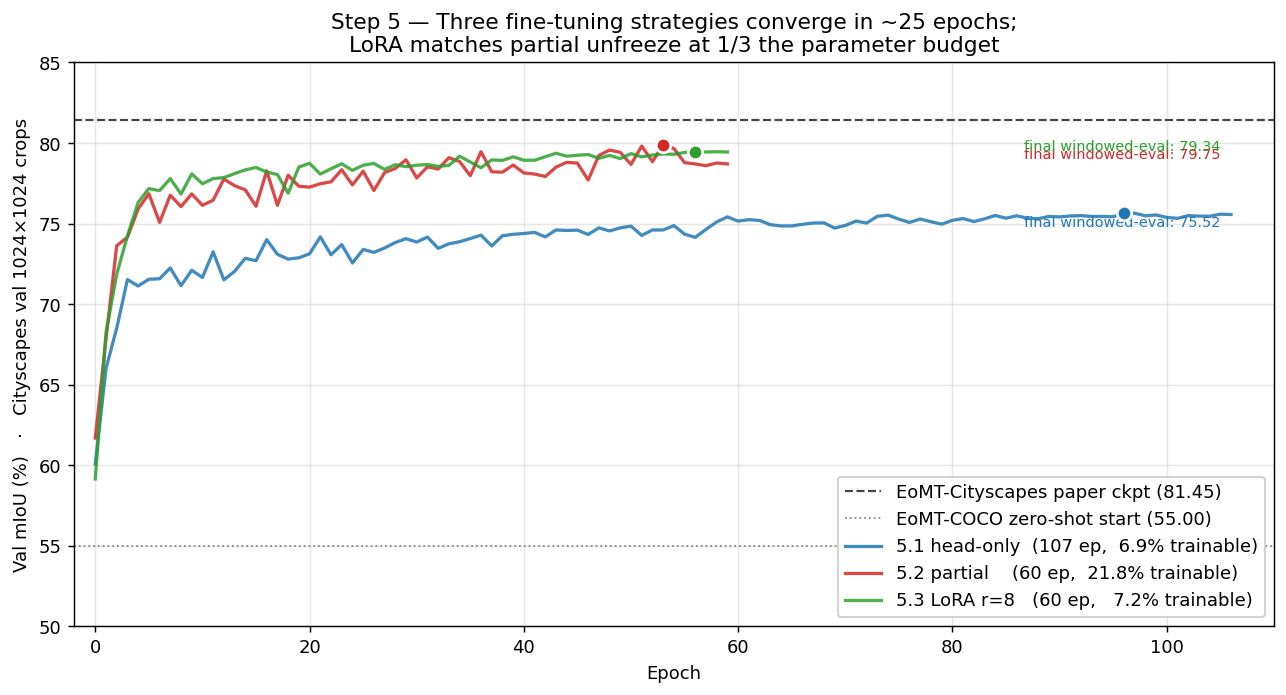


✅ Step 5 convergence chart rendered


In [ ]:
# ── STEP 5 · Convergence trajectories of all three strategies ──
# Per-epoch validation mIoU on Cityscapes val, captured during training.
# Data fetched once from wandb runs (wl0hf8h8, ghlkafzn, mm2zp30q) and
# hardcoded below so the chart regenerates offline.
#
# Note: these are Lightning's in-training val mIoU on 1024x1024 random crops.
# The peaks match the post-training windowed-eval mIoU at native 1024x2048
# within ~0.2 mIoU (see STEP5_RESULTS.md).

import matplotlib.pyplot as plt
import numpy as np

# Each value = val mIoU at end of that epoch (fractional, multiply by 100 for %)
v51 = [0.6007, 0.6600, 0.6850, 0.7152, 0.7112, 0.7154, 0.7157, 0.7224, 0.7114, 0.7210, 0.7165, 0.7324, 0.7150, 0.7203, 0.7284, 0.7269, 0.7400, 0.7309, 0.7279, 0.7287, 0.7312, 0.7417, 0.7306, 0.7369, 0.7255, 0.7339, 0.7321, 0.7348, 0.7382, 0.7406, 0.7385, 0.7416, 0.7346, 0.7374, 0.7387, 0.7407, 0.7428, 0.7361, 0.7424, 0.7433, 0.7438, 0.7445, 0.7417, 0.7460, 0.7457, 0.7459, 0.7432, 0.7473, 0.7454, 0.7473, 0.7484, 0.7426, 0.7460, 0.7460, 0.7487, 0.7434, 0.7414, 0.7464, 0.7510, 0.7541, 0.7515, 0.7524, 0.7519, 0.7493, 0.7485, 0.7485, 0.7495, 0.7503, 0.7504, 0.7472, 0.7488, 0.7515, 0.7503, 0.7545, 0.7552, 0.7527, 0.7507, 0.7528, 0.7511, 0.7496, 0.7520, 0.7531, 0.7512, 0.7529, 0.7550, 0.7533, 0.7548, 0.7533, 0.7530, 0.7544, 0.7541, 0.7547, 0.7549, 0.7544, 0.7544, 0.7542, 0.7564, 0.7564, 0.7548, 0.7553, 0.7538, 0.7532, 0.7549, 0.7546, 0.7545, 0.7558, 0.7556]
v52 = [0.6168, 0.6785, 0.7362, 0.7415, 0.7590, 0.7685, 0.7507, 0.7676, 0.7605, 0.7684, 0.7613, 0.7645, 0.7776, 0.7735, 0.7709, 0.7607, 0.7827, 0.7613, 0.7800, 0.7731, 0.7726, 0.7747, 0.7759, 0.7834, 0.7740, 0.7825, 0.7705, 0.7816, 0.7842, 0.7896, 0.7783, 0.7852, 0.7838, 0.7909, 0.7885, 0.7797, 0.7946, 0.7821, 0.7819, 0.7863, 0.7814, 0.7807, 0.7792, 0.7850, 0.7880, 0.7875, 0.7770, 0.7923, 0.7956, 0.7942, 0.7867, 0.7981, 0.7884, 0.7990, 0.7966, 0.7878, 0.7870, 0.7859, 0.7876, 0.7870]
v53 = [0.5914, 0.6823, 0.7185, 0.7423, 0.7631, 0.7717, 0.7704, 0.7779, 0.7683, 0.7808, 0.7747, 0.7779, 0.7785, 0.7810, 0.7833, 0.7848, 0.7820, 0.7804, 0.7688, 0.7851, 0.7874, 0.7807, 0.7840, 0.7871, 0.7830, 0.7862, 0.7873, 0.7836, 0.7865, 0.7853, 0.7862, 0.7866, 0.7855, 0.7861, 0.7918, 0.7882, 0.7846, 0.7895, 0.7892, 0.7914, 0.7893, 0.7893, 0.7915, 0.7936, 0.7918, 0.7924, 0.7928, 0.7905, 0.7923, 0.7903, 0.7934, 0.7914, 0.7925, 0.7932, 0.7930, 0.7941, 0.7946, 0.7944, 0.7946, 0.7944]

# Final windowed-eval mIoU at native 1024x2048 (from STEP5_RESULTS.md)
windowed_eval = {
    '5.1 head-only': 75.52,
    '5.2 partial':   79.75,
    '5.3 LoRA':      79.34,
}
EOMT_CS_REF = 81.45      # EoMT-Cityscapes baseline (paper checkpoint, same eval pipeline)
COCO_ZS    = 55.00       # EoMT-COCO zero-shot (mapped) starting point

fig, ax = plt.subplots(figsize=(10, 5.5))

# Reference lines first (so curves sit on top)
ax.axhline(EOMT_CS_REF, ls='--', color='#444', lw=1.2,
           label=f'EoMT-Cityscapes paper ckpt ({EOMT_CS_REF:.2f})')
ax.axhline(COCO_ZS, ls=':', color='#888', lw=1.0,
           label=f'EoMT-COCO zero-shot start ({COCO_ZS:.2f})')

# Convergence curves
curves = [
    ('5.1 head-only  (107 ep,  6.9% trainable)', v51, '#1f77b4'),  # blue
    ('5.2 partial    (60 ep,  21.8% trainable)', v52, '#d62728'),  # red
    ('5.3 LoRA r=8   (60 ep,   7.2% trainable)', v53, '#2ca02c'),  # green
]
for label, vals, color in curves:
    xs = np.arange(len(vals))
    ys = np.array(vals) * 100   # to percent
    ax.plot(xs, ys, label=label, color=color, lw=1.8, alpha=0.85)
    # Mark the peak (best epoch)
    peak_i = int(np.argmax(ys))
    ax.plot(peak_i, ys[peak_i], 'o', color=color, ms=8, mec='white', mew=1.5, zorder=5)

ax.set_xlabel('Epoch')
ax.set_ylabel('Val mIoU (%)   ·   Cityscapes val 1024×1024 crops')
ax.set_title('Step 5 — Three fine-tuning strategies converge in ~25 epochs;\nLoRA matches partial unfreeze at 1/3 the parameter budget')
ax.set_ylim(50, 85)
ax.set_xlim(-2, 110)
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', framealpha=0.95)

# Annotate final windowed-eval mIoU off-axis
for (label, _, color), (_, final_val) in zip(curves, windowed_eval.items()):
    ax.annotate(f'final windowed-eval: {final_val:.2f}',
                xy=(105, final_val), color=color, fontsize=8,
                ha='right', va='bottom' if 'LoRA' in label else 'top')

plt.tight_layout()
plt.savefig('/tmp/step5_convergence.png', dpi=130, bbox_inches='tight')
plt.show()
print('\n✅ Step 5 convergence chart rendered')


In [ ]:
# ── STEP 5 · Cell K: Commit & push P2 work to GitHub ─────
# Pushes Step 5 configs, fixed dataloader, and LoRA cells.
import os, subprocess
from google.colab import userdata

token = userdata.get('Shahrzad_Git')
os.system(f'git -C /content/project remote set-url origin https://{token}@github.com/Shayan19950405/FAMLDL.git')

os.system('echo "__pycache__/" >> /content/project/p1_infra/.gitignore')
os.system('git -C /content/project add p1_infra/ eomt/configs/finetune/')
os.system('git -C /content/project commit -m "[P2] Step 5 complete: head-only (75.52) + partial (79.75) + LoRA"')
os.system('git -C /content/project push origin p2-train')

def run(cmd):
    return subprocess.run(cmd, shell=True, capture_output=True, text=True, cwd='/content/project').stdout.strip()
print('\nLast commit local :', run('git log --oneline -1'))
print('Last commit remote:', run('git log --oneline -1 origin/p2-train'))
print('✅ P2 work pushed to origin/p2-train')



Last commit local : 26b44ee [P2] Step 5.1 head-only + 5.2 partial complete; fix dataloader (native resolution, no normalize); add finetune configs
Last commit remote: 26b44ee [P2] Step 5.1 head-only + 5.2 partial complete; fix dataloader (native resolution, no normalize); add finetune configs
✅ P2 work pushed to origin/p2-train


---
## STEP 7 — Pixel-Based Anomaly Baselines (ERFNet)
**Owner: Mim (P3) · Branch: `p3-baselines`**

Apply post-hoc anomaly methods on ERFNet predictions:
- **MSP**: `score = 1 − max softmax(logits)`
- **MaxLogit**: `score = −max logits`  (already implemented in `eval/evalAnomaly.py`)
- **MaxEntropy**: `score = −Σ p·log(p)`

Evaluate on 5 anomaly datasets (RA-21, RO-21, FS L&F, FS Static, Road Anomaly).
Fill Table 1 (ERFNet rows).

---

In [ ]:
# Step 7 cells implemented in branch p3-baselines
print('Step 7 — see branch p3-baselines')

---
## STEP 8 — Mask-Based Anomaly Baselines (EoMT)
**Owner: Shabab (P4) · Branch: `p4-eval`**

Apply post-hoc anomaly methods on all 3 EoMT checkpoints (COCO, Cityscapes, Fine-tuned):
- MSP · MaxLogit · MaxEntropy · **RbA** (mask-specific)
- RbA formula (Nayal et al. 2023, Eq. 5):  `RbA(x) = -Σ_k σ(L_k(x))`
  where `L_k(x) = Σ_q sigmoid(mask_q(x)) * softmax(class_q)[k]`
- Temperature scaling sweep: save logits once, try T ∈ {0.5, 0.75, 1.1, best}

Fill Table 1 (EoMT rows) and Table 2 (temperature scaling).

---

# Functions Define

In [2]:
# ── STEP 8 — Cell 1: All Functions ──
import os, sys, glob, json
import numpy as np
import torch
import torch.nn.functional as F
from pathlib import Path
from PIL import Image
from torchvision.transforms import Compose, Resize, ToTensor
from sklearn.metrics import average_precision_score, roc_curve
from tqdm import tqdm

os.chdir('/content/project/eomt')
sys.path.insert(0, '/content/project/eomt')
from models.eomt import EoMT
from models.vit import ViT

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
ANOMALY_ROOT = Path('/content/anomaly_datasets/Validation_Dataset')
DATASETS = {
    'SMIYC_RA21':   ANOMALY_ROOT / 'RoadObsticle21/images/*.webp',
    'SMIYC_RO21':   ANOMALY_ROOT / 'RoadAnomaly21/images/*.png',
    'FS_LostFound': ANOMALY_ROOT / 'FS_LostFound_full/images/*.png',
    'FS_Static':    ANOMALY_ROOT / 'fs_static/images/*.jpg',
    'RoadAnomaly':  ANOMALY_ROOT / 'RoadAnomaly/images/*.jpg',
}

def load_eomt(ckpt_path, num_classes, num_q, img_size):
    enc = ViT(img_size=img_size, patch_size=16,
              backbone_name='vit_base_patch14_reg4_dinov2')
    model = EoMT(encoder=enc, num_classes=num_classes, num_q=num_q,
                 num_blocks=3, masked_attn_enabled=True)
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    sd = ckpt.get('state_dict', ckpt) if isinstance(ckpt, dict) else ckpt
    clean = {k[len('network.'):]: v for k, v in sd.items()
             if k.startswith('network.')}
    model.load_state_dict(clean, strict=False)
    return model.eval().to(DEVICE)

@torch.no_grad()
def to_per_pixel_logits(mask_logits, class_logits):
    cls = class_logits.softmax(dim=-1)[..., :-1]
    return torch.einsum('bqhw,bqc->bchw', mask_logits.sigmoid(), cls)

def score_msp(pl):
    return (1 - pl.softmax(dim=0).max(dim=0).values).cpu().numpy()

def score_maxlogit(pl):
    return (-pl.max(dim=0).values).cpu().numpy()

def score_maxentropy(pl):
    p = pl.softmax(dim=0)
    return (-(p * p.log()).sum(dim=0)).cpu().numpy()

def score_rba(ml, cl):
    cls = cl.softmax(dim=-1)[:, :-1].max(dim=-1).values
    msk = ml.sigmoid()
    scores = cls[:, None, None].expand_as(msk) * msk
    return (-scores.max(dim=0).values).cpu().numpy()

def fpr_at_95_tpr(scores, labels):
    fpr, tpr, _ = roc_curve(labels, scores)
    return fpr[np.argmin(np.abs(tpr - 0.95))]

def compute_metrics(score_list, gt_list):
    scores = np.concatenate([s.flatten() for s in score_list])
    gts    = np.concatenate([g.flatten() for g in gt_list])
    valid  = gts != 255
    scores = scores[valid]
    gts    = gts[valid]
    ood = scores[gts == 1]
    ind = scores[gts == 0]
    val_out   = np.concatenate([ind, ood])
    val_label = np.concatenate([np.zeros(len(ind)), np.ones(len(ood))])
    auprc = average_precision_score(val_label, val_out) * 100
    fpr   = fpr_at_95_tpr(val_out, val_label) * 100
    return auprc, fpr

def load_gt(path, pathGT, img_size):
    mask = np.array(
        Image.open(pathGT).resize(
            (img_size[1], img_size[0]), Image.NEAREST))
    if 'RoadAnomaly' in pathGT:
        mask = np.where(mask == 2, 1, mask)
    # FS_LostFound_full: already [0=normal, 1=anomaly, 255=ignore]
    return mask

def eval_one(model, glob_pattern, img_size):
    paths = sorted(glob.glob(str(glob_pattern)))
    if not paths:
        print(f'    [WARN] No images found: {glob_pattern}')
        return None
    input_tf = Compose([Resize(img_size, Image.BILINEAR), ToTensor()])
    scores = {m: [] for m in ['msp','maxlogit','maxentropy','rba']}
    gts = []
    for path in tqdm(paths, leave=False):
        pathGT = path.replace('images', 'labels_masks')
        if 'RoadObsticle21' in pathGT: pathGT = pathGT.replace('webp','png')
        if 'fs_static'      in pathGT: pathGT = pathGT.replace('jpg','png')
        if 'RoadAnomaly'    in pathGT: pathGT = pathGT.replace('jpg','png')
        if not os.path.exists(pathGT): continue
        gt = load_gt(path, pathGT, img_size)
        if 1 not in np.unique(gt): continue
        img = input_tf(Image.open(path).convert('RGB')).to(DEVICE)
        with torch.no_grad():
            ml, cl = model(img.unsqueeze(0) / 255.0)
            ml = F.interpolate(ml[-1], img_size,
                               mode='bilinear', align_corners=False)
            cl = cl[-1]
            pl = to_per_pixel_logits(ml, cl).squeeze(0)
            ml0 = ml.squeeze(0)
            cl0 = cl.squeeze(0)
        scores['msp'].append(score_msp(pl))
        scores['maxlogit'].append(score_maxlogit(pl))
        scores['maxentropy'].append(score_maxentropy(pl))
        scores['rba'].append(score_rba(ml0, cl0))
        gts.append(gt)
        torch.cuda.empty_cache()
    if not gts:
        print('    [WARN] No valid images found')
        return None
    results = {}
    for m, sl in scores.items():
        auprc, fpr = compute_metrics(sl, gts)
        results[m] = {'auprc': round(auprc,2), 'fpr95': round(fpr,2)}
        print(f'    {m:<12} AuPRC={auprc:.1f}  FPR95={fpr:.1f}')
    return results

print(" All functions defined!")

 All functions defined!


# Main Evaluation (3 models × 5 datasets)

In [3]:
# ── STEP 8 — Cell 2: Main Evaluation ──
CHECKPOINTS = {
    'EoMT_COCO': {
        'path': '/content/checkpoints/eomt_coco.bin',
        'num_classes': 133, 'num_q': 200, 'img_size': (640, 640),
    },
    'EoMT_Cityscapes': {
        'path': '/content/checkpoints/eomt_cityscapes.bin',
        'num_classes': 19, 'num_q': 100, 'img_size': (1024, 1024),
    },
    'EoMT_Finetuned': {
        'path': '/content/drive/MyDrive/FAMLDL/checkpoints/exp_5_2_partial.bin',
        'num_classes': 19, 'num_q': 100, 'img_size': (1024, 1024),
    },
}

OUT = Path('/content/drive/MyDrive/FAMLDL/results/step8')
OUT.mkdir(parents=True, exist_ok=True)
all_results = {}

for ckpt_name, cfg in CHECKPOINTS.items():
    print(f'\n{"="*50}')
    print(f'Model: {ckpt_name}')
    print(f'{"="*50}')
    if not Path(cfg['path']).exists():
        print(f'[SKIP] checkpoint not found: {cfg["path"]}')
        continue
    model = load_eomt(cfg['path'], cfg['num_classes'],
                      cfg['num_q'], cfg['img_size'])
    all_results[ckpt_name] = {}
    for ds_name, ds_glob in DATASETS.items():
        print(f'\n  Dataset: {ds_name}')
        res = eval_one(model, ds_glob, cfg['img_size'])
        if res:
            all_results[ckpt_name][ds_name] = res
    with open(OUT / f'{ckpt_name}.json', 'w') as f:
        json.dump(all_results[ckpt_name], f, indent=2)
    print(f'\n {ckpt_name} results saved')
    del model
    torch.cuda.empty_cache()

with open(OUT / 'all_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print('\n ALL EXPERIMENTS COMPLETE!')


Model: EoMT_COCO


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]


  Dataset: SMIYC_RA21


    msp          AuPRC=0.7  FPR95=95.5
    maxlogit     AuPRC=0.4  FPR95=93.6
    maxentropy   AuPRC=0.6  FPR95=95.9
    rba          AuPRC=0.4  FPR95=94.0

  Dataset: SMIYC_RO21


...

    msp          AuPRC=0.8  FPR95=90.8
    maxlogit     AuPRC=0.8  FPR95=90.7
    maxentropy   AuPRC=0.7  FPR95=93.7
    rba          AuPRC=0.8  FPR95=90.7

  Dataset: SMIYC_RO21


    msp          AuPRC=15.6  FPR95=93.1
    maxlogit     AuPRC=15.6  FPR95=93.0
    maxentropy   AuPRC=14.7  FPR95=93.9
    rba          AuPRC=15.6  FPR95=93.0

  Dataset: FS_LostFound


    msp          AuPRC=0.3  FPR95=93.9
    maxlogit     AuPRC=0.3  FPR95=93.8
    maxentropy   AuPRC=0.3  FPR95=94.0
    rba          AuPRC=0.3  FPR95=93.8

  Dataset: FS_Static


    msp          AuPRC=2.2  FPR95=92.3
    maxlogit     AuPRC=2.3  FPR95=92.6
    maxentropy   AuPRC=2.1  FPR95=93.9
    rba          AuPRC=2.3  FPR95=92.6

  Dataset: RoadAnomaly


    msp          AuPRC=10.5  FPR95=92.6
    maxlogit     AuPRC=10.6  FPR95=92.5
    maxentropy   AuPRC=9.8  FPR95=93.9
    rba          AuPRC=10.6  FPR95=92.5

 EoMT_Finetuned results saved

 ALL EXPERIMENTS COMPLETE!


## Temperature Scaling

In [4]:
# ── STEP 8 — Cell 3: Temperature Scaling ──
from scipy.optimize import minimize_scalar
from scipy.special import softmax as sp_softmax

input_tf = Compose([Resize((1024,1024), Image.BILINEAR), ToTensor()])
OUT = Path('/content/drive/MyDrive/FAMLDL/results/step8')

# Load fine-tuned model
print("Loading EoMT_Finetuned...")
model = load_eomt(
    '/content/drive/MyDrive/FAMLDL/checkpoints/exp_5_2_partial.bin',
    num_classes=19, num_q=100, img_size=(1024, 1024)
)
print(" Model loaded")

# Collect logits for calibration
print("\nCollecting logits for calibration...")
all_logits, all_gts = [], []
for path in sorted(glob.glob(str(ANOMALY_ROOT / 'RoadAnomaly/images/*.jpg'))):
    pathGT = path.replace('images','labels_masks').replace('jpg','png')
    if not Path(pathGT).exists(): continue
    gt = load_gt(path, pathGT, (1024,1024))
    if 1 not in np.unique(gt): continue
    img = input_tf(Image.open(path).convert('RGB')).to(DEVICE)
    with torch.no_grad():
        ml, cl = model(img.unsqueeze(0) / 255.0)
        ml = F.interpolate(ml[-1], (1024,1024), mode='bilinear', align_corners=False)
        pl = to_per_pixel_logits(ml, cl[-1]).squeeze(0)
    all_logits.append(pl.cpu().numpy())
    all_gts.append(gt)
    torch.cuda.empty_cache()
print(f"Collected {len(all_logits)} images")

# Optimize T
def nll(T):
    T = max(T, 1e-3)
    total, count = 0, 0
    for logits, gt in zip(all_logits, all_gts):
        valid = gt != 255
        flat = logits[:, valid].T
        normal = gt[valid] == 0
        if normal.sum() == 0: continue
        scaled = flat[normal] / T
        probs = sp_softmax(scaled, axis=1)
        total += -np.log(probs.max(axis=1) + 1e-8).mean()
        count += 1
    return total / max(count, 1)

result = minimize_scalar(nll, bounds=(0.5, 5.0), method='bounded')
T_opt = result.x
print(f"\n Optimal T = {T_opt:.4f}")

# Evaluate all T values
TEMPS  = [1.0, 0.5, 0.75, 1.1, T_opt]
LABELS = ['MSP', 'MSP (T=0.5)', 'MSP (T=0.75)', 'MSP (T=1.1)', 'MSP (best T)']
table2 = {}

for T, label in zip(TEMPS, LABELS):
    print(f'\n── {label} (T={T:.3f}) ──')
    table2[label] = {'T': float(T)}
    for ds_name, ds_glob in DATASETS.items():
        paths = sorted(glob.glob(str(ds_glob)))
        score_list, gt_list = [], []
        for path in paths:
            pathGT = path.replace('images','labels_masks')
            if 'RoadObsticle21' in pathGT: pathGT = pathGT.replace('webp','png')
            if 'fs_static'      in pathGT: pathGT = pathGT.replace('jpg','png')
            if 'RoadAnomaly'    in pathGT: pathGT = pathGT.replace('jpg','png')
            if not Path(pathGT).exists(): continue
            gt = load_gt(path, pathGT, (1024,1024))
            if 1 not in np.unique(gt): continue
            img = input_tf(Image.open(path).convert('RGB')).to(DEVICE)
            with torch.no_grad():
                ml, cl = model(img.unsqueeze(0) / 255.0)
                ml = F.interpolate(ml[-1], (1024,1024), mode='bilinear', align_corners=False)
                pl = to_per_pixel_logits(ml, cl[-1]).squeeze(0)
            score_list.append(score_msp(pl / T))
            gt_list.append(gt)
            torch.cuda.empty_cache()
        if not gt_list: continue
        auprc, fpr = compute_metrics(score_list, gt_list)
        table2[label][ds_name] = {'auprc': round(auprc,2), 'fpr95': round(fpr,2)}
        print(f'  {ds_name}: AuPRC={auprc:.1f} FPR95={fpr:.1f}')

with open(OUT / 'table2_temperature_scaling.json', 'w') as f:
    json.dump(table2, f, indent=2)
print(f'\n Temperature scaling done! (best T={T_opt:.4f})')
del model
torch.cuda.empty_cache()

Loading EoMT_Finetuned...
 Model loaded

Collected 60 images

 Optimal T = 0.5000

── MSP (T=1.000) ──
  SMIYC_RA21: AuPRC=0.8 FPR95=90.8
  SMIYC_RO21: AuPRC=15.6 FPR95=93.1
  FS_LostFound: AuPRC=0.3 FPR95=93.9
  FS_Static: AuPRC=2.2 FPR95=92.3
  RoadAnomaly: AuPRC=10.5 FPR95=92.6

── MSP (T=0.5) (T=0.500) ──
  SMIYC_RA21: AuPRC=0.8 FPR95=90.5
  SMIYC_RO21: AuPRC=15.7 FPR95=92.9
  FS_LostFound: AuPRC=0.3 FPR95=93.8
  FS_Static: AuPRC=2.3 FPR95=92.6
  RoadAnomaly: AuPRC=10.5 FPR95=92.5

── MSP (T=0.75) (T=0.750) ──
  SMIYC_RA21: AuPRC=0.8 FPR95=90.8
  SMIYC_RO21: AuPRC=15.6 FPR95=92.9
  FS_LostFound: AuPRC=0.3 FPR95=93.8
  FS_Static: AuPRC=2.3 FPR95=92.8
  RoadAnomaly: AuPRC=10.5 FPR95=92.5

── MSP (T=1.1) (T=1.100) ──
  SMIYC_RA21: AuPRC=0.8 FPR95=90.5
  SMIYC_RO21: AuPRC=15.5 FPR95=93.0
  FS_LostFound: AuPRC=0.3 FPR95=94.0
  FS_Static: AuPRC=2.2 FPR95=92.4
  RoadAnomaly: AuPRC=10.4 FPR95=92.3

── MSP (best T) (T=0.500) ──
  SMIYC_RA21: AuPRC=0.8 FPR95=90.5
  SMIYC_RO21: AuPRC=15.7 FPR

##  Results Table Print

In [5]:
# STEP 8 - Cell 4: Print filled markdown tables
import json
from pathlib import Path

OUT = Path('/content/drive/MyDrive/FAMLDL/results/step8')

with open(OUT / 'all_results.json') as f:
    all_res = json.load(f)
with open(OUT / 'table2_temperature_scaling.json') as f:
    t2 = json.load(f)

DS = ['SMIYC_RA21','SMIYC_RO21','FS_LostFound','FS_Static','RoadAnomaly']
MIOU = {'EoMT_COCO': 55.00, 'EoMT_Cityscapes': 81.45, 'EoMT_Finetuned': 79.75}

def g(model, ds, method):
    try:
        r = all_res[model][ds][method]
        return f"{r['auprc']}", f"{r['fpr95']}"
    except:
        return '', ''

def gt2(label, ds):
    try:
        r = t2[label][ds]
        return f"{r['auprc']}", f"{r['fpr95']}"
    except:
        return '', ''

md = """---
## Results Tables

**Table 1 — Main baselines**

| Model | mIoU | Method | RA-21 AuPRC | RA-21 FPR95 | RO-21 AuPRC | RO-21 FPR95 | FS L&F AuPRC | FS L&F FPR95 | FS Static AuPRC | FS Static FPR95 | Road Anomaly AuPRC | Road Anomaly FPR95 |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| ERFNet | — | MSP | | | | | | | | | | |
| ERFNet | — | MaxLogit | | | | | | | | | | |
| ERFNet | — | MaxEntropy | | | | | | | | | | |\n"""

rows = [
    ('EoMT-COCO',      'EoMT_COCO',      ['msp','maxlogit','maxentropy','rba']),
    ('EoMT-Cityscapes','EoMT_Cityscapes', ['msp','maxlogit','maxentropy','rba']),
    ('EoMT-Finetuned', 'EoMT_Finetuned',  ['msp','maxlogit','maxentropy','rba']),
]

for display, key, methods in rows:
    miou = MIOU.get(key, '')
    for i, method in enumerate(methods):
        m = miou if i == 0 else ''
        vals = []
        for ds in DS:
            a, f = g(key, ds, method)
            vals += [a, f]
        md += f"| {display} | {m} | {method} | {' | '.join(vals)} |\n"

md += """\n**Table 2 — Temperature scaling (MSP)**

| Method | mIoU | RA-21 AuPRC | RA-21 FPR95 | RO-21 AuPRC | RO-21 FPR95 | FS L&F AuPRC | FS L&F FPR95 | FS Static AuPRC | FS Static FPR95 | Road Anomaly AuPRC | Road Anomaly FPR95 |
|---|---|---|---|---|---|---|---|---|---|---|---|
"""

for label in ['MSP','MSP (T=0.5)','MSP (T=0.75)','MSP (T=1.1)','MSP (best T)']:
    vals = []
    for ds in DS:
        a, f = gt2(label, ds)
        vals += [a, f]
    miou = '79.75' if label == 'MSP' else ''
    md += f"| {label} | {miou} | {' | '.join(vals)} |\n"

print(md)

---
## Results Tables

**Table 1 — Main baselines**

| Model | mIoU | Method | RA-21 AuPRC | RA-21 FPR95 | RO-21 AuPRC | RO-21 FPR95 | FS L&F AuPRC | FS L&F FPR95 | FS Static AuPRC | FS Static FPR95 | Road Anomaly AuPRC | Road Anomaly FPR95 |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| ERFNet | — | MSP | | | | | | | | | | |
| ERFNet | — | MaxLogit | | | | | | | | | | |
| ERFNet | — | MaxEntropy | | | | | | | | | | |
| EoMT-COCO | 55.0 | msp | 0.7 | 95.47 | 15.36 | 94.65 | 0.3 | 92.7 | 2.18 | 95.38 | 9.87 | 95.09 |
| EoMT-COCO |  | maxlogit | 0.43 | 93.64 | 15.76 | 84.25 | 0.28 | 88.21 | 1.71 | 89.16 | 8.29 | 94.67 |
| EoMT-COCO |  | maxentropy | 0.63 | 95.86 | 16.4 | 92.81 | 0.3 | 89.07 | 2.14 | 91.82 | 9.68 | 93.84 |
| EoMT-COCO |  | rba | 0.43 | 94.01 | 15.71 | 84.34 | 0.28 | 88.58 | 1.71 | 89.48 | 8.27 | 94.84 |
| EoMT-Cityscapes | 81.45 | msp | 0.37 | 99.85 | 12.17 | 92.93 | 0.41 | 65.13 | 2.57 | 87.76 | 8.76 | 93.01 |
| EoMT-Cityscapes |  | maxlogit | 0.37 | 99.86 | 12

---
## Results Tables

**Table 1 — Main baselines**

| Model | mIoU | Method | RA-21 AuPRC | RA-21 FPR95 | RO-21 AuPRC | RO-21 FPR95 | FS L&F AuPRC | FS L&F FPR95 | FS Static AuPRC | FS Static FPR95 | Road Anomaly AuPRC | Road Anomaly FPR95 |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| ERFNet | — | MSP | | | | | | | | | | |
| ERFNet | — | MaxLogit | | | | | | | | | | |
| ERFNet | — | MaxEntropy | | | | | | | | | | |
| EoMT-COCO | 55.0 | msp | 0.7 | 95.47 | 15.36 | 94.65 | 0.3 | 92.7 | 2.18 | 95.38 | 9.87 | 95.09 |
| EoMT-COCO |  | maxlogit | 0.43 | 93.64 | 15.76 | 84.25 | 0.28 | 88.21 | 1.71 | 89.16 | 8.29 | 94.67 |
| EoMT-COCO |  | maxentropy | 0.63 | 95.86 | 16.4 | 92.81 | 0.3 | 89.07 | 2.14 | 91.82 | 9.68 | 93.84 |
| EoMT-COCO |  | rba | 0.43 | 94.01 | 15.71 | 84.34 | 0.28 | 88.58 | 1.71 | 89.48 | 8.27 | 94.84 |
| EoMT-Cityscapes | 81.45 | msp | 0.37 | 99.85 | 12.17 | 92.93 | 0.41 | 65.13 | 2.57 | 87.76 | 8.76 | 93.01 |
| EoMT-Cityscapes |  | maxlogit | 0.37 | 99.86 | 12.18 | 92.93 | 0.41 | 65.1 | 2.57 | 87.45 | 8.6 | 92.92 |
| EoMT-Cityscapes |  | maxentropy | 0.38 | 99.87 | 12.79 | 92.92 | 0.43 | 65.1 | 2.98 | 87.41 | 8.7 | 92.86 |
| EoMT-Cityscapes |  | rba | 0.37 | 99.69 | 12.15 | 93.32 | 0.4 | 65.26 | 2.54 | 90.65 | 8.55 | 93.29 |
| EoMT-Finetuned | 79.75 | msp | 0.76 | 90.82 | 15.55 | 93.12 | 0.3 | 93.86 | 2.24 | 92.32 | 10.46 | 92.56 |
| EoMT-Finetuned |  | maxlogit | 0.84 | 90.65 | 15.65 | 92.96 | 0.32 | 93.84 | 2.35 | 92.59 | 10.57 | 92.47 |
| EoMT-Finetuned |  | maxentropy | 0.67 | 93.65 | 14.71 | 93.86 | 0.28 | 94.01 | 2.06 | 93.93 | 9.78 | 93.88 |
| EoMT-Finetuned |  | rba | 0.84 | 90.65 | 15.65 | 92.97 | 0.32 | 93.84 | 2.35 | 92.59 | 10.57 | 92.47 |

**Table 2 — Temperature scaling (MSP)**

| Method | mIoU | RA-21 AuPRC | RA-21 FPR95 | RO-21 AuPRC | RO-21 FPR95 | FS L&F AuPRC | FS L&F FPR95 | FS Static AuPRC | FS Static FPR95 | Road Anomaly AuPRC | Road Anomaly FPR95 |
|---|---|---|---|---|---|---|---|---|---|---|---|
| MSP | 79.75 | 0.76 | 90.82 | 15.55 | 93.12 | 0.3 | 93.86 | 2.24 | 92.32 | 10.46 | 92.56 |
| MSP (T=0.5) |  | 0.78 | 90.53 | 15.68 | 92.92 | 0.31 | 93.8 | 2.27 | 92.58 | 10.54 | 92.5 |
| MSP (T=0.75) |  | 0.77 | 90.78 | 15.6 | 92.92 | 0.3 | 93.83 | 2.25 | 92.76 | 10.5 | 92.53 |
| MSP (T=1.1) |  | 0.76 | 90.51 | 15.54 | 92.95 | 0.3 | 94.01 | 2.24 | 92.39 | 10.44 | 92.29 |
| MSP (best T) |  | 0.78 | 90.53 | 15.68 | 92.92 | 0.31 | 93.8 | 2.27 | 92.58 | 10.54 | 92.5 |

In [ ]:
import subprocess

def run(cmd):
    return subprocess.run(cmd, shell=True, capture_output=True, text=True,
                          cwd='/content/project').stdout.strip()

run('git config user.name "Shabab"')
run('git config user.email "ashabab181@gmail.com"')

# Notebook copy করো
import shutil
shutil.copy('/content/drive/MyDrive/FAMLDL/FAMLDL.ipynb',
            '/content/project/FAMLDL.ipynb')

# Status check
print(run('git status --short'))